# Анализ системы метрик приложения

Procrastinate Pro+, приложение, предоставляющее пользователям доступ к развлекательному контенту: видео, подкастам и блогам. Пользователи могут выбрать несколько пакетов контента. Пакеты различаются по цене, объёму и содержанию.

К началу лета в приложении появился новый вид контента — спортивный. С его помощью менеджеры стремятся расширить аудиторию, добавив в неё пользователей, которые увлекаются спортом и здоровым образом жизни.

К запуску нового контента была скорректирована маркетинговая стратегия привлечения пользователей. Согласно бизнес-модели продукта, привлечение должно окупиться за первые 28 дней (4 недели).

После запуска нового контента и изменения стратегии интерес к продукту в целом вырос, но выручка начала стагнировать. Нужно разобраться, почему это происходит.

Задачи:
- провести анализ юнит-экономики продукта в динамике за первые 28 дней;
- разобраться в причинах стагнации выручки;
- определить, какие источники привлечения приносят прибыль, а какие не выходят на уровень окупаемости;
- дать рекомендации отделу маркетинга.


### Данные

Данные собраны в трёх датасетах.

1. Датасет `ppro_visits.csv` — информация о посещениях приложения пользователями, которые зарегистрировались с 1 апреля 2024 года по 30 ноября 2024 года:
    - `user_id` — уникальный идентификатор пользователя;
    - `region` — страна пользователя;
    - `device` — категория устройства пользователя;
    - `channel` — идентификатор рекламного источника, из которого пришёл пользователь;
    - `session_start` — дата и время начала сессии;
    - `session_end` — дата и время окончания сессии.

2. Датасет `ppro_orders.csv` — информация о покупках:
    - `user_id` — уникальный идентификатор пользователя, который сделал покупку;
    - `event_dt` — дата и время покупки;
    - `revenue` — выручка.

3. Датасет `ppro_costs.csv` — информация о затратах на маркетинг:
    - `dt` — дата
    - `channel` — идентификатор рекламного источника;
    - `costs` — затраты на этот рекламный источник в этот день.
    
### План проекта
- Загрузить и предобработать данные.
- Подготовить данные для когортного анализа.
- Рассчитать и проанализировать метрики вовлечённости в продукт.
- Рассчитать и проанализировать финансовые метрики CAC, LTV и ROI за первые 28 дней с момента привлечения.
- Исследовать метрики в разрезе источника привлечения.
- Рассчитать период окупаемости маркетинговых вложений.
- Сформулировать выводы и рекомендации.


## Загрузка и предобработка данных

Загрузим данные и получим основную информацию о них. Далее проведем необходимую предобработку. 

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings

# Игнорировать все предупреждения
warnings.filterwarnings("ignore")

In [2]:
pip install fsspec

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
paths = ['https://code.s3.yandex.net/datasets/ppro_visits.csv', 
         'https://code.s3.yandex.net/datasets/ppro_orders.csv', 
         'https://code.s3.yandex.net/datasets/ppro_costs.csv']

local_paths = ['D://Яндекс практикум/Проект пятого модуля/ppro_visits.csv',
               'D://Яндекс практикум/Проект пятого модуля/ppro_orders.csv',
               'D://Яндекс практикум/Проект пятого модуля/ppro_costs.csv']

In [4]:
df_list = []

In [5]:
try:
    for path in local_paths:
        df_list.append(pd.read_csv(path))
    print("Данные успешно загружены из локальной директории.")
except FileNotFoundError:
    try:
        for path in paths:
            df_list.append(pd.read_csv(path))
        print("Данные успешно загружены из удаленной директории.")
    except FileNotFoundError as e:
        print(f"Ошибка: {e}. Проверьте, что файл находится в указанной директории или укажите правильный путь!")

for frame in df_list:
    display(frame.info(), frame.head(10))

Данные успешно загружены из локальной директории.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161865 entries, 0 to 161864
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   user_id        161865 non-null  int64 
 1   region         161865 non-null  object
 2   device         161865 non-null  object
 3   channel        161865 non-null  object
 4   session_start  161865 non-null  object
 5   session_end    161865 non-null  object
dtypes: int64(1), object(5)
memory usage: 7.4+ MB


None

,user_id,region,device,channel,session_start,session_end
0,631105188566,India,desktop,MediaTornado,2024-04-01 03:48:00,2024-04-01 04:19:00
1,892885906464,India,tv,RocketSuperAds,2024-04-01 00:47:00,2024-04-01 01:14:00
2,517003690029,India,mobile,MediaTornado,2024-04-01 17:31:00,2024-04-01 17:53:00
3,185156659289,India,mobile,MediaTornado,2024-04-01 14:36:00,2024-04-01 14:51:00
4,409503040345,India,mobile,RocketSuperAds,2024-04-01 08:25:00,2024-04-01 08:45:00
5,479040246649,India,desktop,FaceBoom,2024-04-01 06:08:00,2024-04-01 06:37:00
6,570274684514,India,tv,FaceBoom,2024-04-01 19:21:00,2024-04-01 21:24:00
7,936183070403,India,mobile,MediaTornado,2024-04-01 01:07:00,2024-04-01 01:28:00
8,454863096888,India,mobile,RocketSuperAds,2024-04-01 18:06:00,2024-04-01 18:34:00
9,105472059485,India,mobile,TipTop,2024-04-01 18:54:00,2024-04-01 19:29:00


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33893 entries, 0 to 33892
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   user_id   33893 non-null  int64  
 1   event_dt  33893 non-null  object 
 2   revenue   33893 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 794.5+ KB


None

,user_id,event_dt,revenue
0,771951256319,2024-04-01 05:56:26,2.99
1,829942381059,2024-04-01 14:55:02,2.99
2,727879856738,2024-04-01 22:15:09,14.99
3,481270888930,2024-04-01 06:05:14,2.99
4,844695029762,2024-04-01 01:19:52,2.99
5,601982992004,2024-04-01 19:02:56,2.99
6,373037757367,2024-04-01 21:48:58,2.99
7,588009939701,2024-04-01 06:32:32,4.49
8,550254063862,2024-04-01 18:53:41,4.49
9,328482322349,2024-04-01 04:47:07,2.99


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 976 entries, 0 to 975
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   dt       976 non-null    object 
 1   channel  976 non-null    object 
 2   costs    976 non-null    float64
dtypes: float64(1), object(2)
memory usage: 23.0+ KB


None

,dt,channel,costs
0,2024-04-01,FaceBoom,124.938874
1,2024-04-02,FaceBoom,88.147779
2,2024-04-03,FaceBoom,120.779457
3,2024-04-04,FaceBoom,98.981253
4,2024-04-05,FaceBoom,109.044760
5,2024-04-06,FaceBoom,108.248285
6,2024-04-07,FaceBoom,119.735493
7,2024-04-08,FaceBoom,106.880336
8,2024-04-09,FaceBoom,106.306183
9,2024-04-10,FaceBoom,98.713647


In [6]:
visits = df_list[0]
orders = df_list[1]
costs = df_list[2]

In [7]:
def check_duplicates(frame):
    duplicates = frame.groupby(frame.columns.to_list()).size().reset_index(name='count')
    duplicates = duplicates[duplicates['count'] > 1]    
    duplicates_count = duplicates['count'].sum()    
    duplicates_part = duplicates_count / len(frame)
    
    print(f'Количество дубликатов: {duplicates_count}')
    print(f'Доля дубликатов: {round(duplicates_part, 3)}')
    print(f'Доля дубликатов в процентах: {round(duplicates_part * 100, 3)}%\n')

In [8]:
check_duplicates(visits)

Количество дубликатов: 0
Доля дубликатов: 0.0
Доля дубликатов в процентах: 0.0%



In [9]:
check_duplicates(orders)

Количество дубликатов: 0
Доля дубликатов: 0.0
Доля дубликатов в процентах: 0.0%



In [10]:
check_duplicates(costs)

Количество дубликатов: 0
Доля дубликатов: 0.0
Доля дубликатов в процентах: 0.0%



Имеем следующее:

- Пропусков по представленным датафреймам нет
- Дубликатов по представленным датафреймам не обнаружено

## Подготовка данных к когортному анализу

Готовим данные к когортному анализу с учётом того, что мы будем изучать окупаемость привлечения пользователей за первые 28 дней.

Для каждого пользователя найдём:
- дату первой сессии (дата привлечения пользователя, `first_dt`);
- канал привлечения (`first_channel`);
- стоимость привлечения пользователя (`cac`).

Результаты сохраним в новой таблице, `profiles`.

Добавим к данным с событиями и покупками информацию о первом источнике привлечения и дату привлечения пользователя из созданной таблицы. После этого рассчитаем дневной лайфтайм для каждого события или покупки и добавим в таблицу в виде целого числа. В дальнейшем при проведении когортного анализа будем использовать информацию о первом источнике привлечения пользователя.

In [11]:
cols = ['session_start', 'session_end']
visits[cols] = visits[cols].apply(lambda x: pd.to_datetime(x, errors='coerce').dt.date)

orders['event_dt'] = pd.to_datetime(orders['event_dt']).dt.date
costs['dt'] = pd.to_datetime(costs['dt'])

display(visits.head(10), orders.head(10), costs.head(10))
print(visits.columns, orders.columns, costs.columns)

,user_id,region,device,channel,session_start,session_end
0,631105188566,India,desktop,MediaTornado,2024-04-01,2024-04-01
1,892885906464,India,tv,RocketSuperAds,2024-04-01,2024-04-01
2,517003690029,India,mobile,MediaTornado,2024-04-01,2024-04-01
3,185156659289,India,mobile,MediaTornado,2024-04-01,2024-04-01
4,409503040345,India,mobile,RocketSuperAds,2024-04-01,2024-04-01
5,479040246649,India,desktop,FaceBoom,2024-04-01,2024-04-01
6,570274684514,India,tv,FaceBoom,2024-04-01,2024-04-01
7,936183070403,India,mobile,MediaTornado,2024-04-01,2024-04-01
8,454863096888,India,mobile,RocketSuperAds,2024-04-01,2024-04-01
9,105472059485,India,mobile,TipTop,2024-04-01,2024-04-01


,user_id,event_dt,revenue
0,771951256319,2024-04-01,2.99
1,829942381059,2024-04-01,2.99
2,727879856738,2024-04-01,14.99
3,481270888930,2024-04-01,2.99
4,844695029762,2024-04-01,2.99
5,601982992004,2024-04-01,2.99
6,373037757367,2024-04-01,2.99
7,588009939701,2024-04-01,4.49
8,550254063862,2024-04-01,4.49
9,328482322349,2024-04-01,2.99


,dt,channel,costs
0,2024-04-01,FaceBoom,124.938874
1,2024-04-02,FaceBoom,88.147779
2,2024-04-03,FaceBoom,120.779457
3,2024-04-04,FaceBoom,98.981253
4,2024-04-05,FaceBoom,109.044760
5,2024-04-06,FaceBoom,108.248285
6,2024-04-07,FaceBoom,119.735493
7,2024-04-08,FaceBoom,106.880336
8,2024-04-09,FaceBoom,106.306183
9,2024-04-10,FaceBoom,98.713647


Index(['user_id', 'region', 'device', 'channel', 'session_start',
       'session_end'],
      dtype='object') Index(['user_id', 'event_dt', 'revenue'], dtype='object') Index(['dt', 'channel', 'costs'], dtype='object')


In [12]:
# Определяем первую сессию и канал привлечения для каждого пользователя и сохраняем в таблицу profiles
profiles = visits.sort_values(by='session_start').groupby('user_id').agg(
            first_dt = ('session_start', 'min'),
            first_channel = ('channel','first')).reset_index()

profiles = profiles.rename(columns={'session_start': 'first_dt', 'channel': 'first_channel'})

profiles['first_dt'] = pd.to_datetime(profiles['first_dt'], errors='coerce')
profiles['first_dt'] = profiles['first_dt'].dt.normalize()

display(profiles.head())

,user_id,first_dt,first_channel
0,26034876,2024-05-29,FaceBoom
1,69890364,2024-06-28,RocketSuperAds
2,75610104,2024-06-09,FaceBoom
3,76692397,2024-10-21,FaceBoom
4,80224421,2024-06-21,FaceBoom


In [13]:
# Подсчитываем САС по каждому устройству в день
cac_df = (costs
       .groupby(['channel','dt'])['costs'].sum().reset_index()
       .merge(profiles.groupby(['first_channel','first_dt'])['user_id'].nunique(),
              left_on=['dt','channel'],
              right_on=['first_dt','first_channel'], how='inner')
       .assign(cac = lambda x: x['costs']/x['user_id'])
      )
cac_df.columns = ['first_channel', 'first_dt', 'costs', 'user_id', 'cac']

display(cac_df.head())

,first_channel,first_dt,costs,user_id,cac
0,FaceBoom,2024-04-01,124.938874,133,0.939390
1,FaceBoom,2024-04-02,88.147779,94,0.937742
2,FaceBoom,2024-04-03,120.779457,133,0.908116
3,FaceBoom,2024-04-04,98.981253,105,0.942679
4,FaceBoom,2024-04-05,109.044760,110,0.991316


In [14]:
# Добавляем в profiles информацию о САС
profiles = (profiles.merge(cac_df[['first_dt','first_channel','cac']],
                                on=['first_dt','first_channel'],
                                how='left'))

display(profiles.head(), profiles.columns)

,user_id,first_dt,first_channel,cac
0,26034876,2024-05-29,FaceBoom,0.953250
1,69890364,2024-06-28,RocketSuperAds,0.604917
2,75610104,2024-06-09,FaceBoom,1.196159
3,76692397,2024-10-21,FaceBoom,1.147967
4,80224421,2024-06-21,FaceBoom,1.208981


Index(['user_id', 'first_dt', 'first_channel', 'cac'], dtype='object')

Итак, мы получили таблицу profiles, содержащую в себе следующие столбцы, необходимые для анализа:
    
 - 'user_id', 'first_dt', 'first_channel', 'cac'

In [15]:
# Тут я создам вспомогательную таблицу, которая будет использоваться при расчете и визуализации недельного ROI
profiles_for_weekly_ROI = profiles.copy()

In [16]:
# Теперь к данным о событиях и покупках мы добавляем информацию о об источнике привлечения и о дате привлечения
visits = visits.merge(profiles[['user_id','first_dt','first_channel']], on='user_id', how='left')
orders = orders.merge(profiles[['user_id','first_dt','first_channel']], on='user_id', how='left')


display(orders.head(), visits.head())

,user_id,event_dt,revenue,first_dt,first_channel
0,771951256319,2024-04-01,2.99,2024-04-01,FaceBoom
1,829942381059,2024-04-01,2.99,2024-04-01,FaceBoom
2,727879856738,2024-04-01,14.99,2024-04-01,FaceBoom
3,481270888930,2024-04-01,2.99,2024-04-01,TipTop
4,844695029762,2024-04-01,2.99,2024-04-01,FaceBoom


,user_id,region,device,channel,session_start,session_end,first_dt,first_channel
0,631105188566,India,desktop,MediaTornado,2024-04-01,2024-04-01,2024-04-01,MediaTornado
1,892885906464,India,tv,RocketSuperAds,2024-04-01,2024-04-01,2024-04-01,RocketSuperAds
2,517003690029,India,mobile,MediaTornado,2024-04-01,2024-04-01,2024-04-01,MediaTornado
3,185156659289,India,mobile,MediaTornado,2024-04-01,2024-04-01,2024-04-01,MediaTornado
4,409503040345,India,mobile,RocketSuperAds,2024-04-01,2024-04-01,2024-04-01,RocketSuperAds


In [17]:
# Вычисляем lifetime в днях
orders['event_dt'] = pd.to_datetime(orders['event_dt'])
orders['first_dt'] = pd.to_datetime(orders['first_dt'])

visits['session_start'] = pd.to_datetime(visits['session_start'])
visits['first_dt'] = pd.to_datetime(visits['first_dt'])

visits['lifetime'] = (visits['session_start'] - visits['first_dt']).dt.days.astype('int')
orders['lifetime'] = (orders['event_dt'] - orders['first_dt']).dt.days.astype('int')

display(orders.head(), visits.head())

,user_id,event_dt,revenue,first_dt,first_channel,lifetime
0,771951256319,2024-04-01,2.99,2024-04-01,FaceBoom,0
1,829942381059,2024-04-01,2.99,2024-04-01,FaceBoom,0
2,727879856738,2024-04-01,14.99,2024-04-01,FaceBoom,0
3,481270888930,2024-04-01,2.99,2024-04-01,TipTop,0
4,844695029762,2024-04-01,2.99,2024-04-01,FaceBoom,0


,user_id,region,device,channel,session_start,session_end,first_dt,first_channel,lifetime
0,631105188566,India,desktop,MediaTornado,2024-04-01,2024-04-01,2024-04-01,MediaTornado,0
1,892885906464,India,tv,RocketSuperAds,2024-04-01,2024-04-01,2024-04-01,RocketSuperAds,0
2,517003690029,India,mobile,MediaTornado,2024-04-01,2024-04-01,2024-04-01,MediaTornado,0
3,185156659289,India,mobile,MediaTornado,2024-04-01,2024-04-01,2024-04-01,MediaTornado,0
4,409503040345,India,mobile,RocketSuperAds,2024-04-01,2024-04-01,2024-04-01,RocketSuperAds,0


Итак, мы имеем таблице orders и visits всю необходимоую информацию для дальнейшего анализа.

In [18]:
# Дополнительно я скопирую таблицу orders, которая понадобится для анализа недельного ROI
full_orders = orders.copy()

In [19]:
# Фильтруем orders и visits согласно заданию
orders = orders[orders['lifetime'] < 28]
visits = visits[visits['lifetime'] < 28]

display(orders.head(), visits.head(), profiles.head())

,user_id,event_dt,revenue,first_dt,first_channel,lifetime
0,771951256319,2024-04-01,2.99,2024-04-01,FaceBoom,0
1,829942381059,2024-04-01,2.99,2024-04-01,FaceBoom,0
2,727879856738,2024-04-01,14.99,2024-04-01,FaceBoom,0
3,481270888930,2024-04-01,2.99,2024-04-01,TipTop,0
4,844695029762,2024-04-01,2.99,2024-04-01,FaceBoom,0


,user_id,region,device,channel,session_start,session_end,first_dt,first_channel,lifetime
0,631105188566,India,desktop,MediaTornado,2024-04-01,2024-04-01,2024-04-01,MediaTornado,0
1,892885906464,India,tv,RocketSuperAds,2024-04-01,2024-04-01,2024-04-01,RocketSuperAds,0
2,517003690029,India,mobile,MediaTornado,2024-04-01,2024-04-01,2024-04-01,MediaTornado,0
3,185156659289,India,mobile,MediaTornado,2024-04-01,2024-04-01,2024-04-01,MediaTornado,0
4,409503040345,India,mobile,RocketSuperAds,2024-04-01,2024-04-01,2024-04-01,RocketSuperAds,0


,user_id,first_dt,first_channel,cac
0,26034876,2024-05-29,FaceBoom,0.953250
1,69890364,2024-06-28,RocketSuperAds,0.604917
2,75610104,2024-06-09,FaceBoom,1.196159
3,76692397,2024-10-21,FaceBoom,1.147967
4,80224421,2024-06-21,FaceBoom,1.208981


Теперь мы имеем таблицы со всеми необходимыми данными для дальнейшего анализа.

## Анализ месячной динамики основных метрик продукта

**Задача 1**. Начнем анализ данных с изучения динамики активности пользователей и их вовлечённости в продукт. Рассчитаем по всем данным значения DAU, MAU и Stickiness и визуализируем их. Активными будем считать всех пользователей, которые взаимодействовали с приложением.

**Задача 2**. В разрезе каждого месяца привлечения новых пользователей рассчитаем:
- Среднюю стоимость привлечения пользователя (CAC).
- Значение LTV и ROI с учётом покупок, совершённых за 28 дней с момента привлечения.

Здесь и далее при расчёте LTV и ROI будем учитывать всех привлечённых пользователей когорты.

Визуализируем метрики с акцентом на общей динамике изменения метрик с учётом появления нового контента в начале лета.

In [20]:
# Выведем столбцы по таблицам для контроля
display(visits.columns, orders.columns, profiles.columns)

Index(['user_id', 'region', 'device', 'channel', 'session_start',
       'session_end', 'first_dt', 'first_channel', 'lifetime'],
      dtype='object')

Index(['user_id', 'event_dt', 'revenue', 'first_dt', 'first_channel',
       'lifetime'],
      dtype='object')

Index(['user_id', 'first_dt', 'first_channel', 'cac'], dtype='object')

,session_start,DAU
0,2024-04-01,356
1,2024-04-02,410
2,2024-04-03,481
3,2024-04-04,472
4,2024-04-05,533


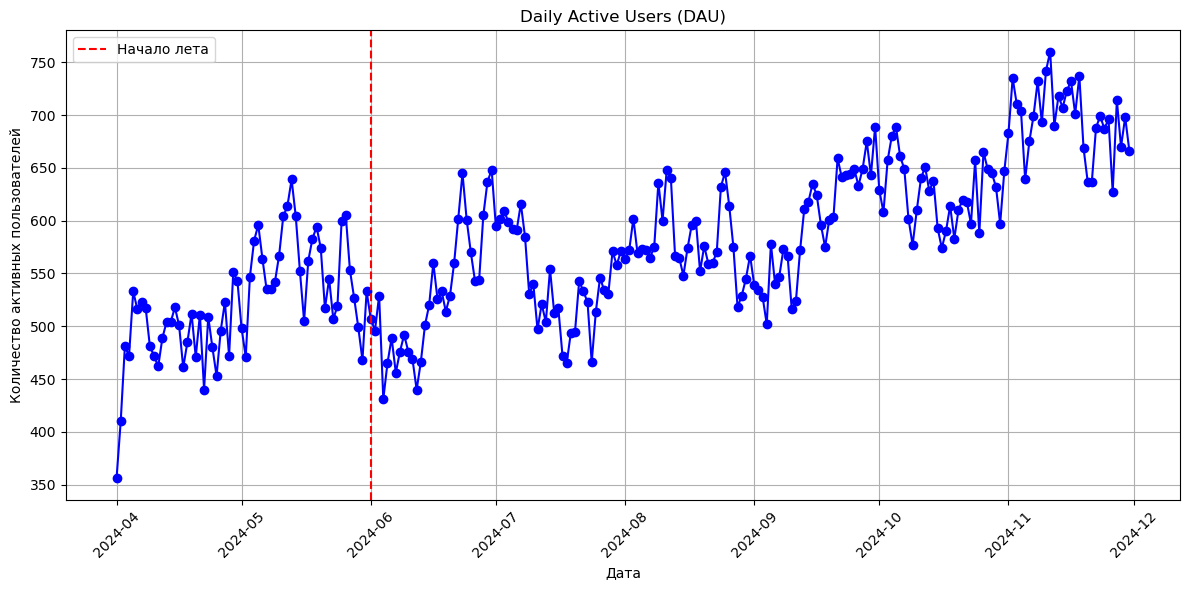

In [21]:
# Рассчитаем DAU по всем пользователям, взаимодействовавшим с приложением  
dau = visits.groupby('session_start')['user_id'].nunique().reset_index(name='DAU')
display(dau.head())

plt.figure(figsize=(12, 6))
plt.plot(dau['session_start'], dau['DAU'], marker='o', color='blue')
plt.title('Daily Active Users (DAU)')
plt.xlabel('Дата')
plt.ylabel('Количество активных пользователей')
plt.xticks(rotation=45)
plt.grid()

# Отмечаем начало лета (2024-06-01)
plt.axvline(pd.Timestamp('2024-06-01'), color='red', linestyle='--', label='Начало лета')

plt.legend()
plt.tight_layout()
plt.show()

График дневного DAU показывает колебания, однако имеется общая тенденция к возрастанию дневной активности пользователей

,month,MAU
0,2024-04,9069
1,2024-05,10598
2,2024-06,9550
3,2024-07,9743
4,2024-08,10495


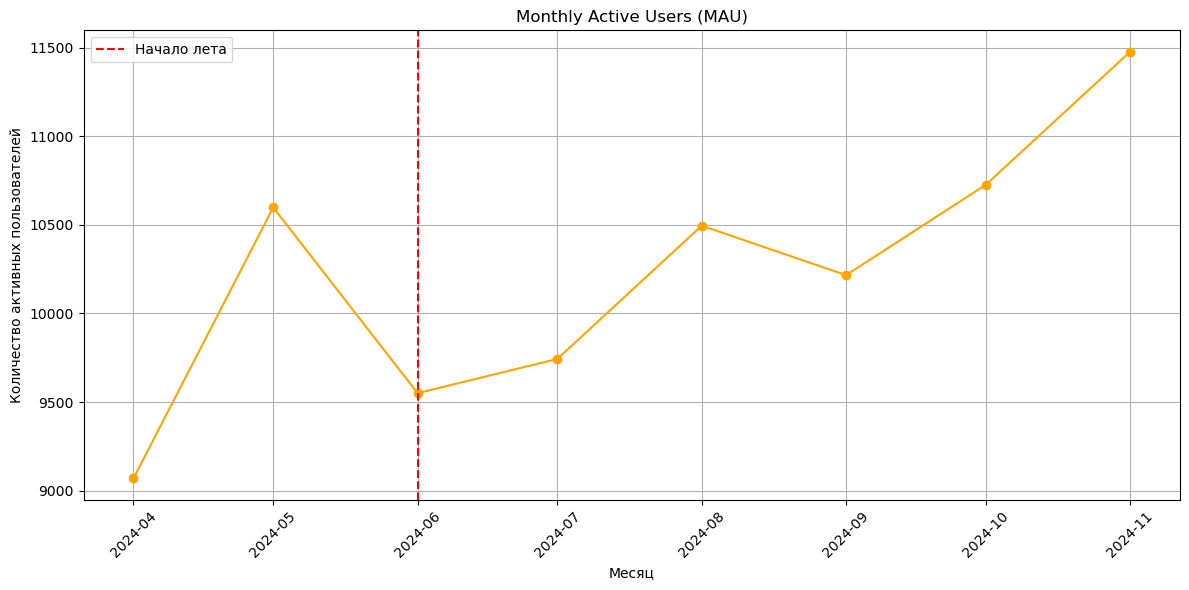

In [22]:
# Рассчитаем MAU
visits['session_start'] = pd.to_datetime(visits['session_start'], errors='coerce')

visits['month'] = visits['session_start'].dt.to_period('M')

mau = visits.groupby('month')['user_id'].nunique().reset_index(name = 'MAU')

display(mau.head())

# Визуализируем MAU
plt.figure(figsize=(12, 6))
plt.plot(mau['month'].dt.to_timestamp(), mau['MAU'], marker='o', color='orange')
plt.title('Monthly Active Users (MAU)')
plt.xlabel('Месяц')
plt.ylabel('Количество активных пользователей')
plt.xticks(rotation=45)
plt.grid()

# Отмечаем начало лета (2024-06-01)
plt.axvline(pd.Timestamp('2024-06-01'), color='red', linestyle='--', label='Начало лета')

plt.legend()
plt.tight_layout()
plt.show()

На графике мы видим похожую тенденцию к росту месячной активности MAU с просадками за периоды с мая по июнь, а также с августа по сентябрь 2024.

,month,MAU,DAU,stickiness
0,2024-04,9069,488.200000,5.38
1,2024-05,10598,552.903226,5.22
2,2024-06,9550,527.666667,5.53
3,2024-07,9743,541.354839,5.56
4,2024-08,10495,580.935484,5.54


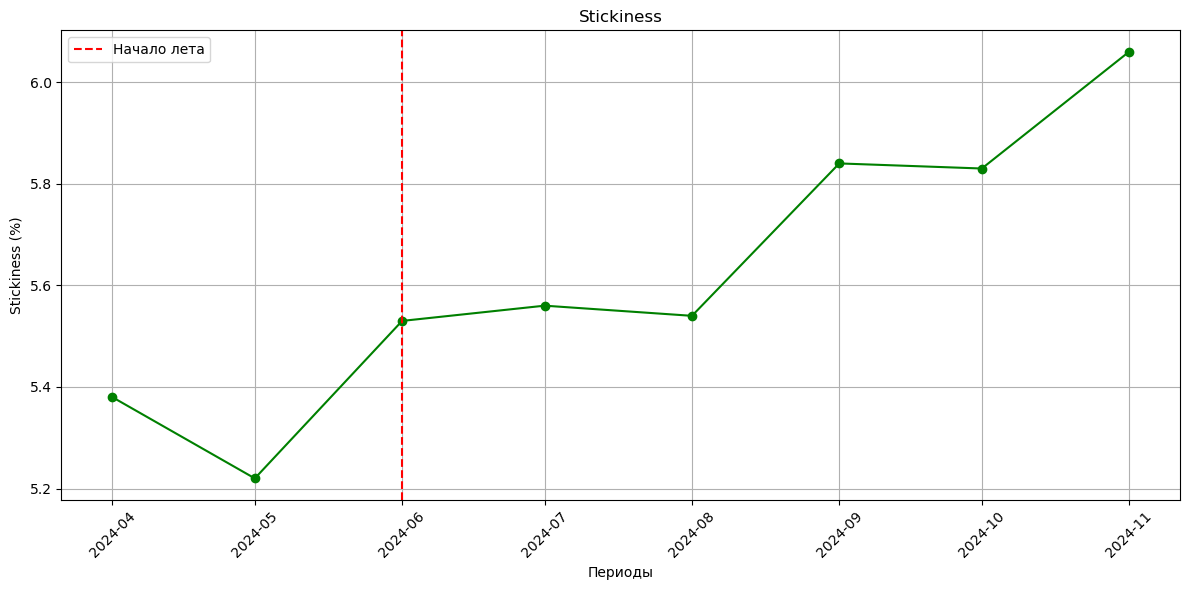

In [23]:
dau['month'] = dau['session_start'].dt.to_period('M')

# Считаем средний DAU
dau_monthly_average = dau.groupby('month')['DAU'].mean().reset_index()

# Объединяем MAU и average DAU
stickiness_df = pd.merge(mau, dau_monthly_average, how='left', on='month')

# Рассчитываем Stickiness
stickiness_df['stickiness'] = ((stickiness_df['DAU'] / stickiness_df['MAU']) * 100).round(2)

display(stickiness_df.head())


# Создаем линейный график для Stickiness
plt.figure(figsize=(12, 6))
plt.plot(stickiness_df['month'].dt.to_timestamp(), stickiness_df['stickiness'], marker='o', color='green')
plt.title('Stickiness')
plt.xlabel('Периоды')
plt.ylabel('Stickiness (%)')
plt.xticks(rotation=45)
plt.grid()

# Отмечаем начало лета (2024-06-01)
plt.axvline(pd.Timestamp('2024-06-01'), color='red', linestyle='--', label='Начало лета')

plt.legend()
plt.tight_layout()
plt.show()

Имеем просадку "залипания" с апреля 2024-04 по май 2024-05, затем наблюдается рост показателя, что говорит об улучшении вовлеченности пользователей, тем не менее сам по себе показатель не высокий, от 5% до 6%, что в свою очередь говорит о том, что менее 10% пользователей возвращаются в приложение каждый день.

In [24]:
# Преобразуем first_dt в месяц привлечения
profiles['acquisition_month'] = profiles['first_dt'].dt.to_period('M')

#Также выделю месяц в orders по дате события
orders['month'] = orders['event_dt'].dt.to_period('M')

# Группируем по месяцу
cac_by_month = profiles.groupby('acquisition_month').agg(
    total_costs=('cac', 'sum'),  # Сумма затрат на привлечение
    unique_users=('user_id', 'nunique')  # Количество уникальных пользователей
).reset_index()

# Рассчитываем среднюю стоимость привлечения (CAC)
cac_by_month['CAC'] = cac_by_month['total_costs'] / cac_by_month['unique_users']

display(cac_by_month.head())

,acquisition_month,total_costs,unique_users,CAC
0,2024-04,6663.052333,9069,0.734706
1,2024-05,7327.775412,9789,0.748572
2,2024-06,8492.116887,8719,0.973978
3,2024-07,9217.078561,8742,1.054344
4,2024-08,10999.013650,9518,1.155601


In [25]:
# Считаем месчную выручку
revenue_per_month = orders.groupby(['user_id', 'month'])['revenue'].sum().reset_index()

display(revenue_per_month.head())

,user_id,month,revenue
0,80224421,2024-06,2.99
1,118088465,2024-07,19.44
2,257716959,2024-11,5.98
3,451288296,2024-09,11.96
4,451288296,2024-10,5.98


In [26]:
# Добавляем выручку информацией о месяце привлечения 
revenue_per_month = revenue_per_month.merge(profiles[['user_id', 'acquisition_month']], on='user_id', how='left')
display(revenue_per_month.head())

,user_id,month,revenue,acquisition_month
0,80224421,2024-06,2.99,2024-06
1,118088465,2024-07,19.44,2024-07
2,257716959,2024-11,5.98,2024-11
3,451288296,2024-09,11.96,2024-09
4,451288296,2024-10,5.98,2024-09


In [27]:
# Группируем по месяцу привлечения и рассчитываем total_revenue
revenue_per_month = revenue_per_month.groupby('acquisition_month')['revenue'].sum().reset_index(name='total_revenue')
display(revenue_per_month.head())

,acquisition_month,total_revenue
0,2024-04,7425.63
1,2024-05,8141.76
2,2024-06,7447.84
3,2024-07,9991.41
4,2024-08,10367.05


In [28]:
# Создаем cac_ltv_roi_df для хранения метрик
cac_ltv_roi_df = pd.merge(cac_by_month[['acquisition_month', 'unique_users', 'CAC']], revenue_per_month, on = 'acquisition_month', how = 'left')

display(cac_ltv_roi_df.head())

,acquisition_month,unique_users,CAC,total_revenue
0,2024-04,9069,0.734706,7425.63
1,2024-05,9789,0.748572,8141.76
2,2024-06,8719,0.973978,7447.84
3,2024-07,8742,1.054344,9991.41
4,2024-08,9518,1.155601,10367.05


In [29]:
# Считаем LTV и ROI
cac_ltv_roi_df['LTV'] = cac_ltv_roi_df['total_revenue']/cac_ltv_roi_df['unique_users']
cac_ltv_roi_df['ROI'] = (cac_ltv_roi_df['LTV'] - cac_ltv_roi_df['CAC'])/cac_ltv_roi_df['CAC']*100

display(cac_ltv_roi_df.head())
print(cac_ltv_roi_df.columns)

,acquisition_month,unique_users,CAC,total_revenue,LTV,ROI
0,2024-04,9069,0.734706,7425.63,0.818793,11.444870
1,2024-05,9789,0.748572,8141.76,0.831725,11.108209
2,2024-06,8719,0.973978,7447.84,0.854208,-12.297015
3,2024-07,8742,1.054344,9991.41,1.142920,8.401051
4,2024-08,9518,1.155601,10367.05,1.089205,-5.745639


Index(['acquisition_month', 'unique_users', 'CAC', 'total_revenue', 'LTV',
       'ROI'],
      dtype='object')


In [30]:
# Исключаем ноябрьскую когорту из анализа, поскольку данные за ноябрь не полные.
cac_ltv_roi_df = cac_ltv_roi_df[cac_ltv_roi_df['acquisition_month'].dt.month != 11]

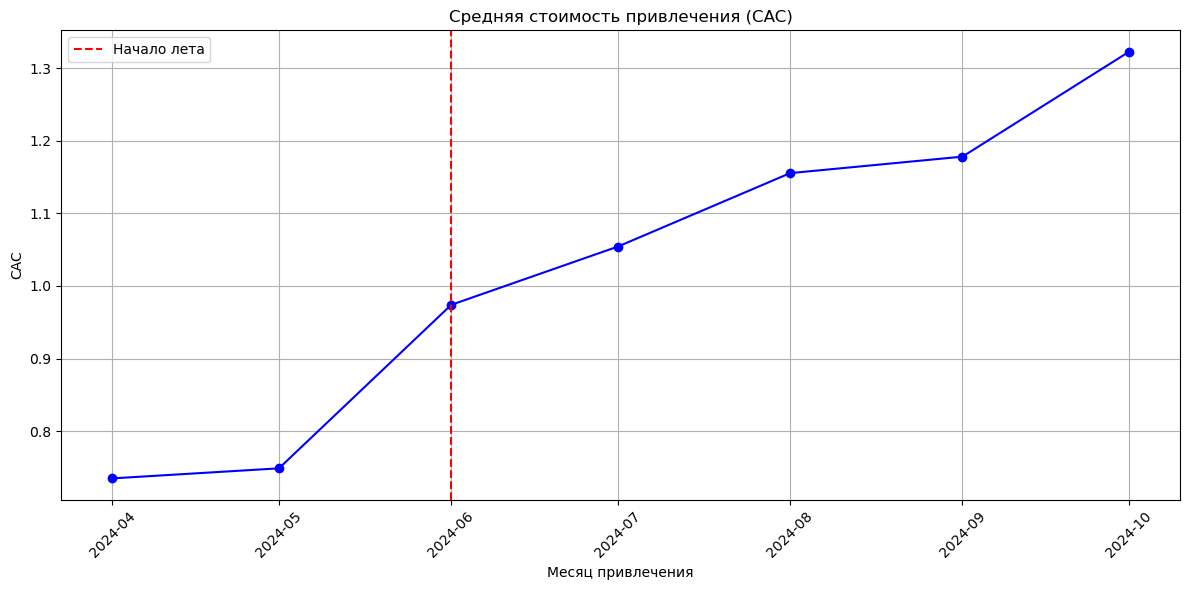

In [31]:
# Визуализируем CAC
plt.figure(figsize=(12, 6))

plt.plot(cac_ltv_roi_df['acquisition_month'].dt.to_timestamp(), cac_ltv_roi_df['CAC'], marker='o', color='blue')
plt.title('Средняя стоимость привлечения (CAC)')
plt.xlabel('Месяц привлечения')
plt.ylabel('CAC')
plt.grid()

# Отмечаем начало лета (2024-06-01)
plt.axvline(pd.Timestamp('2024-06-01'), color='red', linestyle='--', label='Начало лета')

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

График показывает, что месячные затраты на маркетинг довольно быстро растут.

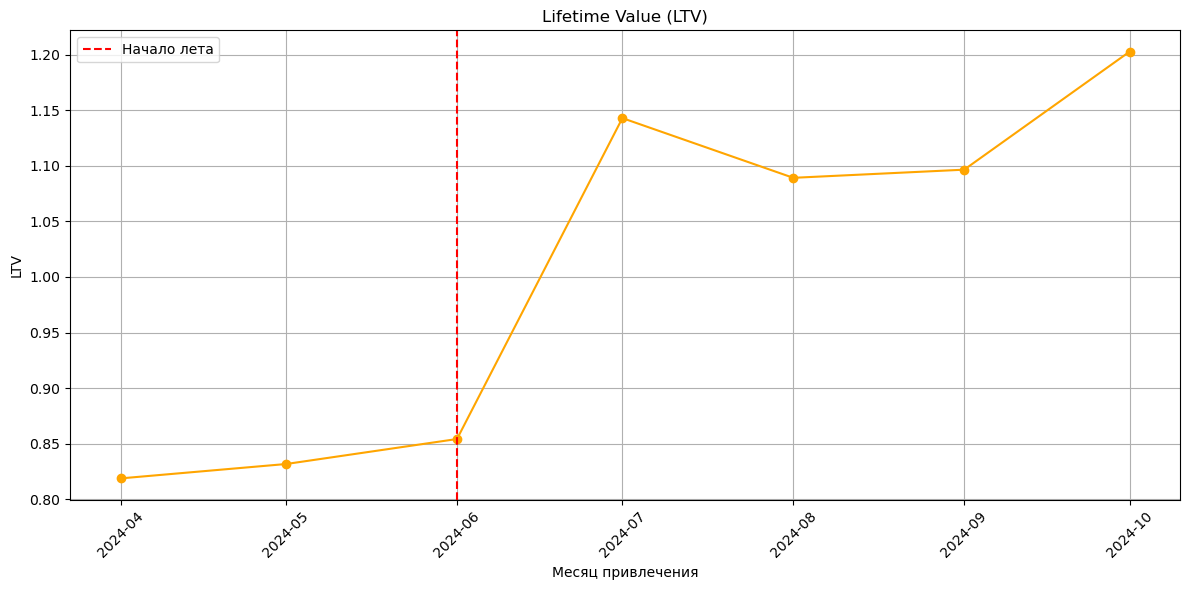

In [32]:
# Визуализируем LTV
plt.figure(figsize=(12, 6))

plt.plot(cac_ltv_roi_df['acquisition_month'].dt.to_timestamp(), cac_ltv_roi_df['LTV'], marker='o', color='orange')
plt.title('Lifetime Value (LTV)')
plt.xlabel('Месяц привлечения')
plt.ylabel('LTV')
plt.grid()

# Отмечаем начало лета (2024-06-01)
plt.axvline(pd.Timestamp('2024-06-01'), color='red', linestyle='--', label='Начало лета')

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Из графика видно, что LTV имеет резкий рост с начала лета до июля, потом мы наблюдаем период небольшого спада с июля 2024 до августа 2024, после чего показатель приобретает стабильный вид с тенденцией к росту до сентября, а затем растет до октября месяца.

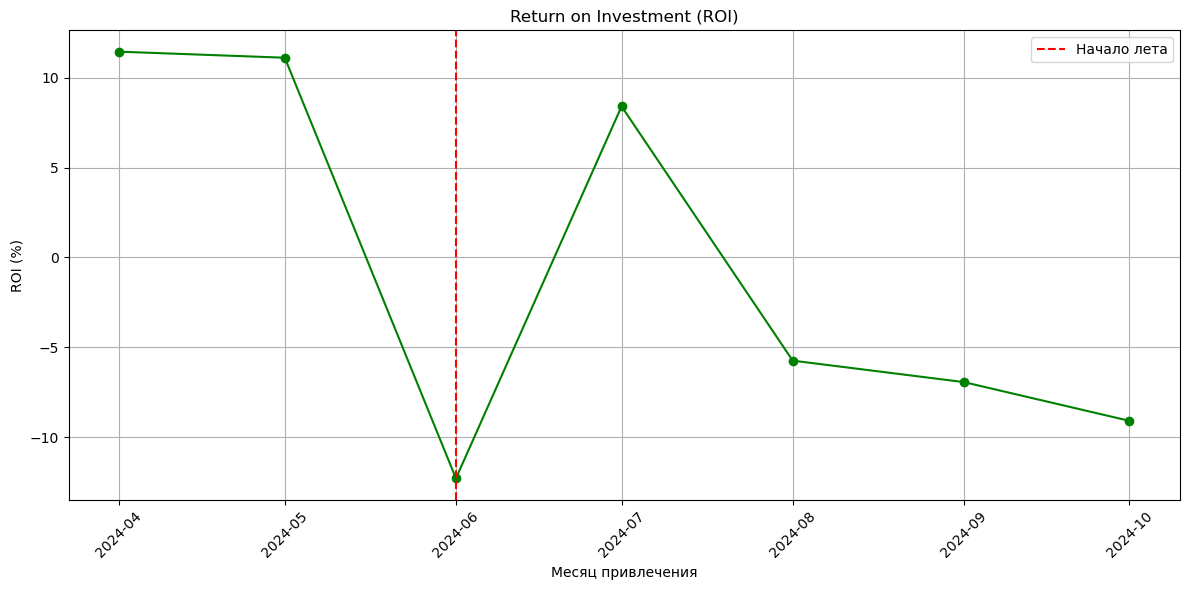

In [33]:
# Визуализируем ROI
plt.figure(figsize=(12, 6))

plt.plot(cac_ltv_roi_df['acquisition_month'].dt.to_timestamp(), cac_ltv_roi_df['ROI'], marker='o', color='green')
plt.title('Return on Investment (ROI)')
plt.xlabel('Месяц привлечения')
plt.ylabel('ROI (%)')
plt.grid()

# Отмечаем начало лета (2024-06-01)
plt.axvline(pd.Timestamp('2024-06-01'), color='red', linestyle='--', label='Начало лета')

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

График показывает падение ROI в период с мая по июнь, затем резкий рост по июль месяц и падает вплоть до октября 2024.

Причины, которые связаны с таким поведением показателя:

- Затраты на привлечение пользователей возросли, но доходы от них не увеличились пропорционально. 
- Рост CAC на фоне роста и последующей стабилизации LTV.

## Анализ метрик в разрезе источника привлечения

Разбираемся, какие источники привлечения перспективны, а какие за 28 дней не окупились.

**Задача 1**. Определяем самые популярные источники привлечения:
- Считаем общее число привлечённых пользователей для каждого источника.
- Визуализируем динамику набора новых пользователей по дням в каждом источнике.
- Считаем и визуализируем динамику DAU, MAU и Stickiness по источникам привлечения.

**Задача 2**. Изучаем динамику изменения метрик на 28-й день в разрезе источника. Проводим анализ с выделением недельных когорт по дате привлечения. Считаем и визуализируем:
- Скользящее удержание на 14-й день с момента привлечения (за период с 14-го по 28-й день).
- Конверсию в покупку.

Недельную динамику затрат на маркетинг по каждому источнику привлечения.
Динамику среднего CAC, значений LTV и ROI.

По результатам проведим анализ рекламных каналов. Составляем общую характеристику каждому рекламному каналу по рассчитанным метрикам. Указываем, какие рекламные каналы не вышли на уровень окупаемости за ожидаемый период, и пробуем предположить почему.


In [34]:
# Выведем столбцы по таблицам для контроля
display(visits.columns, orders.columns, profiles.columns)

Index(['user_id', 'region', 'device', 'channel', 'session_start',
       'session_end', 'first_dt', 'first_channel', 'lifetime', 'month'],
      dtype='object')

Index(['user_id', 'event_dt', 'revenue', 'first_dt', 'first_channel',
       'lifetime', 'month'],
      dtype='object')

Index(['user_id', 'first_dt', 'first_channel', 'cac', 'acquisition_month'], dtype='object')

In [35]:
# Подсчет общего числа привлеченных пользователей по источникам привлечения
user_counts = profiles.groupby('first_channel')['user_id'].nunique().reset_index(name = 'total_users')
user_counts = user_counts.sort_values(by='total_users', ascending=False)

display(user_counts)

,first_channel,total_users
0,FaceBoom,28401
3,TipTop,18118
2,RocketSuperAds,14257
1,MediaTornado,14080


In [36]:
 # Подсчет количества новых пользователей по каналам и месяцам
monthly_user_counts = profiles.groupby(['acquisition_month', 'first_channel'])['user_id'].nunique().reset_index(name='new_users')
monthly_user_counts = monthly_user_counts.sort_values(by=['acquisition_month', 'new_users'], ascending=[True, False])

display(monthly_user_counts.head())

,acquisition_month,first_channel,new_users
0,2024-04,FaceBoom,3170
2,2024-04,RocketSuperAds,2030
1,2024-04,MediaTornado,1969
3,2024-04,TipTop,1900
4,2024-05,FaceBoom,3425


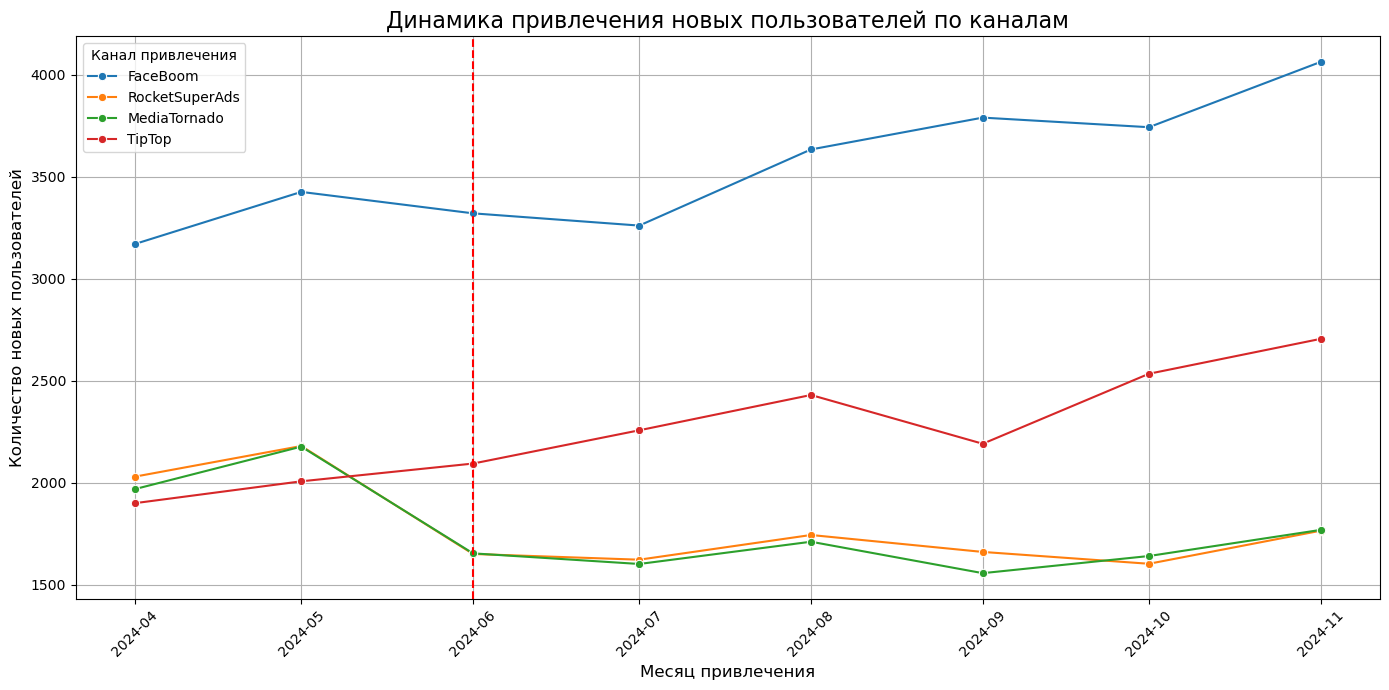

In [37]:
plt.figure(figsize=(14, 7))
sns.lineplot(data=monthly_user_counts, x=monthly_user_counts['acquisition_month'].dt.to_timestamp(), y='new_users', hue='first_channel', marker='o')

plt.title('Динамика привлечения новых пользователей по каналам', fontsize=16)
plt.xlabel('Месяц привлечения', fontsize=12)
plt.ylabel('Количество новых пользователей', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Канал привлечения')
plt.grid()

# Отмечаем начало лета (2024-06-01)
plt.axvline(pd.Timestamp('2024-06-01'), color='red', linestyle='--', label='Начало лета')
plt.tight_layout()

plt.show()

Имеем следующее:
    
- Наибольшее количество новых пользователей было привлечено через канал FaceBoom. Это говорит о том, что данный канал оказался наиболее эффективным по стратегии привлечения.
- В целом все каналы растут по показателю количества привлеченных пользователей, однако источник TipTop оказывается выше остальных каналов и занимает вторую строчку после FaceBoom.

,session_start,first_channel,DAU
0,2024-04-01,FaceBoom,133
1,2024-04-01,MediaTornado,80
3,2024-04-01,TipTop,73
2,2024-04-01,RocketSuperAds,70
4,2024-04-02,FaceBoom,113


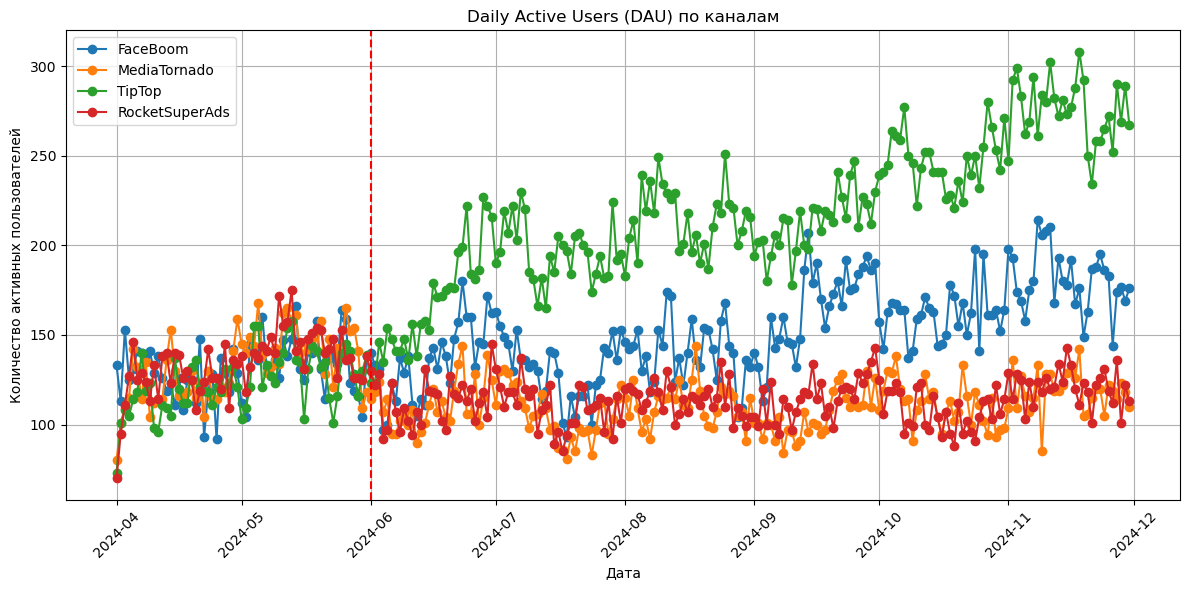

In [38]:
# Рассчитаем DAU по каждому каналу
dau_channel = visits.groupby(['session_start', 'first_channel'])['user_id'].nunique().reset_index(name='DAU')
dau_channel = dau_channel.sort_values(by=['session_start', 'DAU'], ascending=[True, False])

display(dau_channel.head())

# Визуализируем DAU по каналам
plt.figure(figsize=(12, 6))
for channel in dau_channel['first_channel'].unique():
    plt.plot(dau_channel[dau_channel['first_channel'] == channel]['session_start'], 
             dau_channel[dau_channel['first_channel'] == channel]['DAU'], 
             marker='o', label=channel)

plt.title('Daily Active Users (DAU) по каналам')
plt.xlabel('Дата')
plt.ylabel('Количество активных пользователей')
plt.xticks(rotation=45)
plt.legend()
plt.grid()

# Отмечаем начало лета (2024-06-01)
plt.axvline(pd.Timestamp('2024-06-01'), color='red', linestyle='--', label='Начало лета')

plt.tight_layout()
plt.show()

График показывает, что дневная активность пользователей по каналу TipTop растет к концу года, у остальных каналов в целом стабильная картина с колебаниями по дням.

,month,first_channel,MAU
0,2024-04,FaceBoom,3170
2,2024-04,RocketSuperAds,2030
1,2024-04,MediaTornado,1969
3,2024-04,TipTop,1900
4,2024-05,FaceBoom,3506


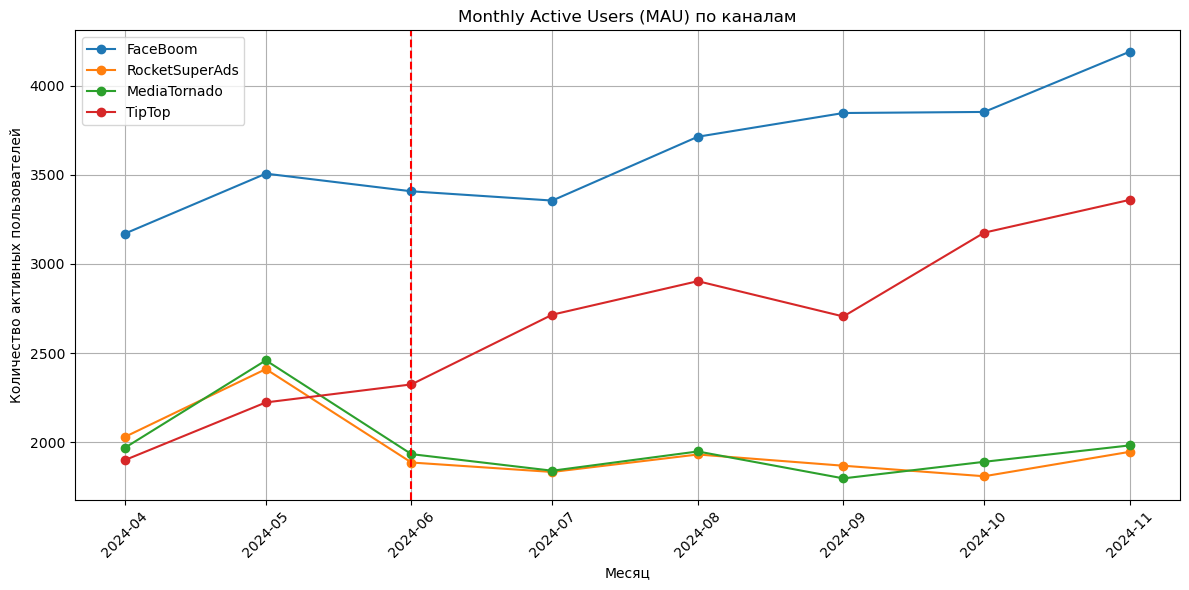

In [39]:
# Рассчитаем MAU по каждому каналу
mau_channel = visits.groupby(['month', 'first_channel'])['user_id'].nunique().reset_index(name='MAU')
mau_channel = mau_channel.sort_values(by=['month', 'MAU'], ascending=[True, False])

display(mau_channel.head())

# Визуализируем MAU по каналам
plt.figure(figsize=(12, 6))
for channel in mau_channel['first_channel'].unique():
    plt.plot(mau_channel[mau_channel['first_channel'] == channel]['month'].dt.to_timestamp(), 
             mau_channel[mau_channel['first_channel'] == channel]['MAU'], 
             marker='o', label=channel)

plt.title('Monthly Active Users (MAU) по каналам')
plt.xlabel('Месяц')
plt.ylabel('Количество активных пользователей')
plt.xticks(rotation=45)
plt.legend()
plt.grid()

# Отмечаем начало лета (2024-06-01)
plt.axvline(pd.Timestamp('2024-06-01'), color='red', linestyle='--', label='Начало лета')

plt.tight_layout()
plt.show()

График показывает, что месячная активность пользователей по каналу TipTop растет к концу года, у остальных каналов в целом стабильная картина с незначительными колебаниями.

,month,first_channel,MAU,DAU,Stickiness
0,2024-04,FaceBoom,3170,126.433333,3.988433
1,2024-04,RocketSuperAds,2030,124.566667,6.136289
2,2024-04,MediaTornado,1969,121.100000,6.150330
3,2024-04,TipTop,1900,116.100000,6.110526
4,2024-05,FaceBoom,3506,135.258065,3.857903


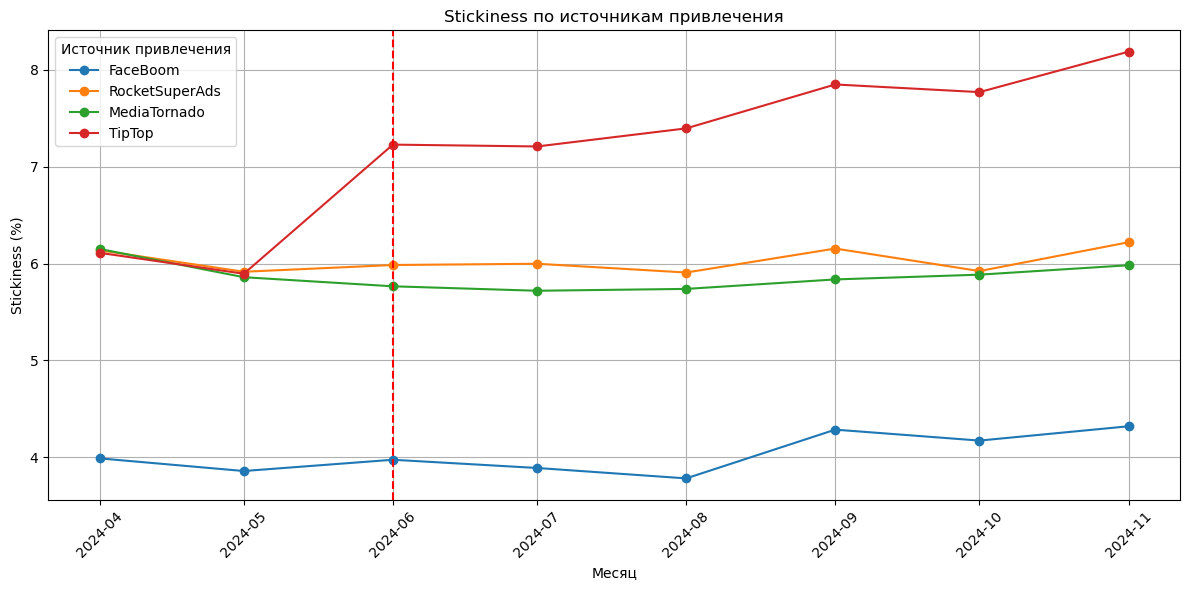

In [40]:
# Рассчитаем Stickiness по каналам
dau_channel['month'] = dau_channel['session_start'].dt.to_period('M')

# Рассчитаем среднее значение DAU по каналам
average_dau_channel = dau_channel.groupby(['first_channel', 'month'])['DAU'].mean().reset_index()


# Предполагаем, что mau_channel также содержит столбец 'month' для объединения
stickiness_per_cahnnel_df = mau_channel.merge(average_dau_channel, on=['month', 'first_channel'], suffixes=('_DAU', '_MAU'), how='left')


# Рассчитываем Stickiness
stickiness_per_cahnnel_df['Stickiness'] = (stickiness_per_cahnnel_df['DAU'] / stickiness_per_cahnnel_df['MAU']) * 100

display(stickiness_per_cahnnel_df.head())

# Визуализируем Stickiness по каналам
plt.figure(figsize=(12, 6))
for platform in stickiness_per_cahnnel_df['first_channel'].unique():
    plt.plot(
        stickiness_per_cahnnel_df[stickiness_per_cahnnel_df['first_channel'] == platform]['month'].dt.to_timestamp(),
        stickiness_per_cahnnel_df[stickiness_per_cahnnel_df['first_channel'] == platform]['Stickiness'],
        label=platform,
        marker='o'  # Добавляем маркеры для лучшей визуализации
    )

plt.title('Stickiness по источникам привлечения')
plt.xlabel('Месяц')
plt.ylabel('Stickiness (%)')
plt.xticks(rotation=45)
plt.legend(title='Источник привлечения')
plt.grid()

# Отмечаем начало лета (2024-06-01)
plt.axvline(pd.Timestamp('2024-06-01'), color='red', linestyle='--', label='Начало лета')

plt.tight_layout()
plt.show()

Stickiness по каналу TipTop сначала снижается в апреле, а затем резко растет до июня, после это выравнивается с тенденцией к дальнейшему росту. Месячный Stickiness по каналам RocketSuperAds, FaceBoom и MediaTornado имеет стабильный вид. Тем не менее можно сказать, что самое малое залипание имеет канал FaceBoom.

In [41]:
# Выделяем неделю привлечения
orders['first_dt'] = pd.to_datetime(orders['first_dt'], errors='coerce')
orders['acquisition_week'] = orders['first_dt'].dt.to_period('W')

display(orders.head())

,user_id,event_dt,revenue,first_dt,first_channel,lifetime,month,acquisition_week
0,771951256319,2024-04-01,2.99,2024-04-01,FaceBoom,0,2024-04,2024-04-01/2024-04-07
1,829942381059,2024-04-01,2.99,2024-04-01,FaceBoom,0,2024-04,2024-04-01/2024-04-07
2,727879856738,2024-04-01,14.99,2024-04-01,FaceBoom,0,2024-04,2024-04-01/2024-04-07
3,481270888930,2024-04-01,2.99,2024-04-01,TipTop,0,2024-04,2024-04-01/2024-04-07
4,844695029762,2024-04-01,2.99,2024-04-01,FaceBoom,0,2024-04,2024-04-01/2024-04-07


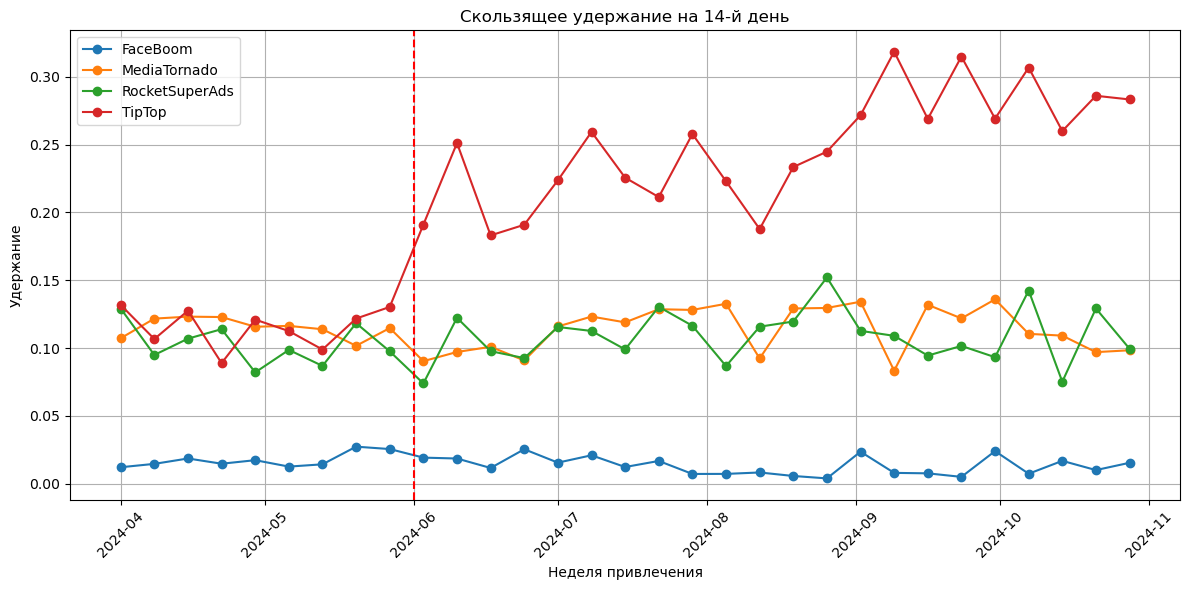

In [42]:
# Удержание на 14-й день
# Группируем по каналу привлечения и неделе
# Выделяем неделю первого посещения
visits['acquisition_week'] = visits['first_dt'].dt.to_period('W').dt.to_timestamp()

# Считаем размер когорт на первый день
visits_28days_first_day = (visits
                       .query('lifetime == 0')
                       .groupby(['first_channel','acquisition_week'])
                       .agg(total_users = ('user_id','nunique')).reset_index()
                      )

# Считаем размер когорт на 14й и последующие дни
visits_28days_n_days = (visits
                       .query('lifetime >= 13')
                       .groupby(['first_channel','acquisition_week'])
                       .agg(n_days_users = ('user_id','nunique')).reset_index()
                      )

# Соединяем данные и считаем скользящее удержание
rr = visits_28days_first_day.merge(visits_28days_n_days, on=['first_channel','acquisition_week'], how='left').fillna(0)
rr['rr_14'] = rr['n_days_users'] / rr['total_users']

# Фильтруем данные по октябрь
rr = rr.query('acquisition_week < "2024-11-01"')

# Визуализируем удержание
plt.figure(figsize=(12, 6))
for channel in rr['first_channel'].unique():
    plt.plot(rr[rr['first_channel'] == channel]['acquisition_week'],
             rr[rr['first_channel'] == channel]['rr_14'], marker='o', label=channel)

plt.title('Скользящее удержание на 14-й день')
plt.xlabel('Неделя привлечения')
plt.ylabel('Удержание')
plt.legend()
plt.xticks(rotation=45)
plt.grid()

# Отмечаем начало лета (2024-06-01)
plt.axvline(pd.Timestamp('2024-06-01'), color='red', linestyle='--', label='Начало лета')

plt.tight_layout()
plt.show()

График показывает, что RR по каналу TipTop с начала лета растет вплоть по октябрь 2024. RR по остальным каналам имеет стабильную картину, однако показатель по каналу FaceBoom самый низкий из всех источников.

In [43]:
# Добавляем переменную acquisition_week в профили
profiles['acquisition_week'] = profiles['first_dt'].dt.to_period('W')

display(profiles.head(), orders.head())

,user_id,first_dt,first_channel,cac,acquisition_month,acquisition_week
0,26034876,2024-05-29,FaceBoom,0.953250,2024-05,2024-05-27/2024-06-02
1,69890364,2024-06-28,RocketSuperAds,0.604917,2024-06,2024-06-24/2024-06-30
2,75610104,2024-06-09,FaceBoom,1.196159,2024-06,2024-06-03/2024-06-09
3,76692397,2024-10-21,FaceBoom,1.147967,2024-10,2024-10-21/2024-10-27
4,80224421,2024-06-21,FaceBoom,1.208981,2024-06,2024-06-17/2024-06-23


,user_id,event_dt,revenue,first_dt,first_channel,lifetime,month,acquisition_week
0,771951256319,2024-04-01,2.99,2024-04-01,FaceBoom,0,2024-04,2024-04-01/2024-04-07
1,829942381059,2024-04-01,2.99,2024-04-01,FaceBoom,0,2024-04,2024-04-01/2024-04-07
2,727879856738,2024-04-01,14.99,2024-04-01,FaceBoom,0,2024-04,2024-04-01/2024-04-07
3,481270888930,2024-04-01,2.99,2024-04-01,TipTop,0,2024-04,2024-04-01/2024-04-07
4,844695029762,2024-04-01,2.99,2024-04-01,FaceBoom,0,2024-04,2024-04-01/2024-04-07


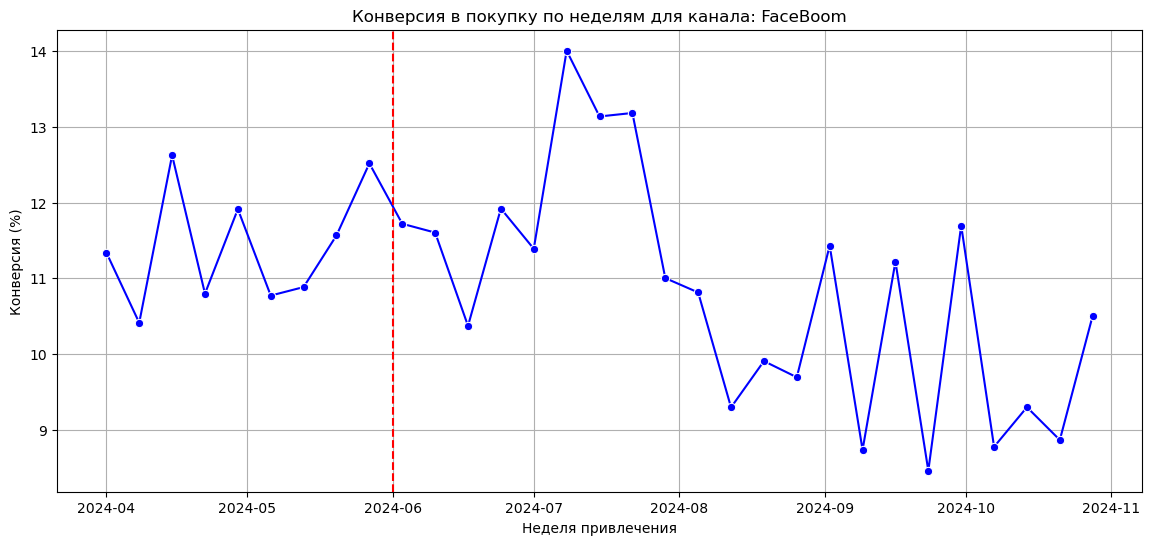

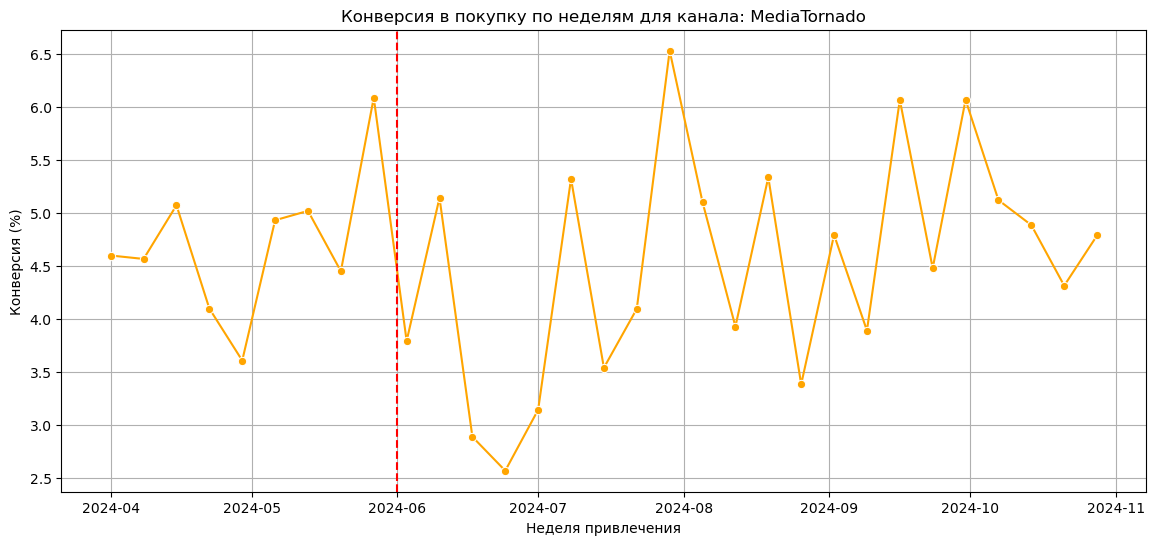

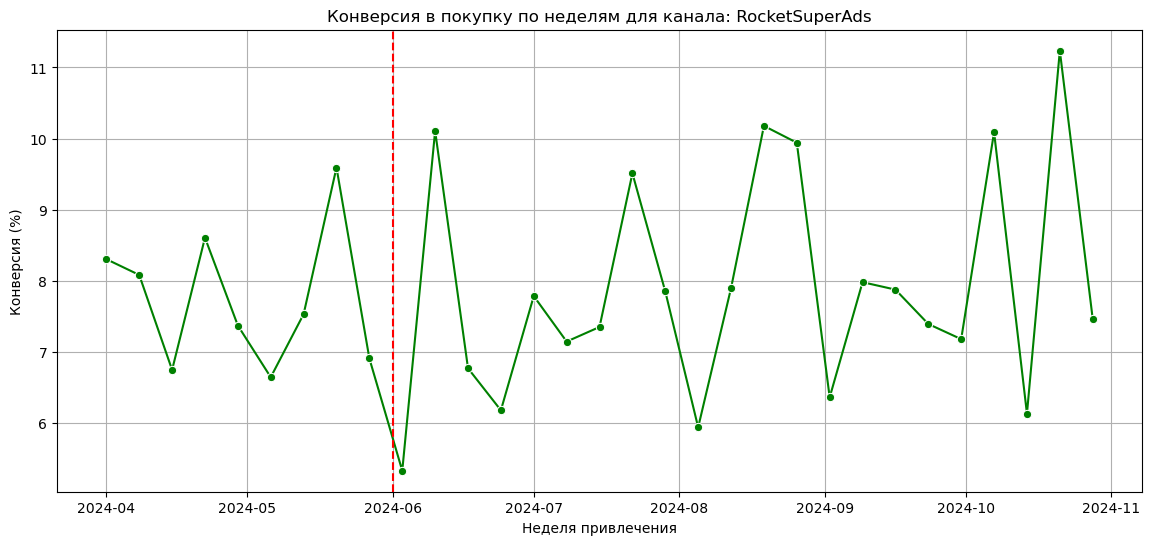

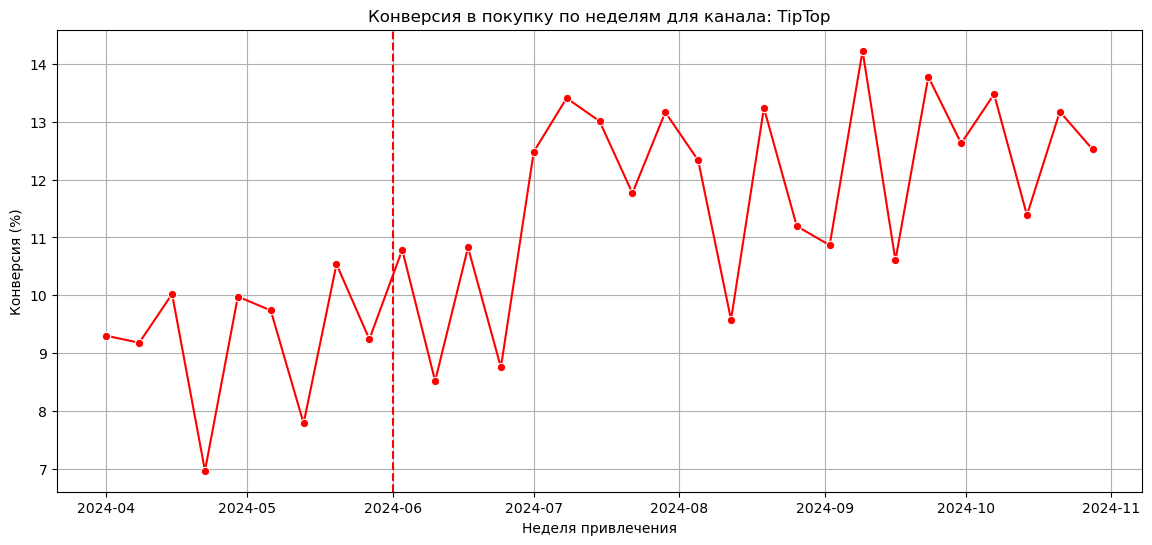

In [44]:
# Подсчитываем уникальных пользователей, которые совершили покупку
purchased_users = orders.groupby(['first_channel', 'acquisition_week'])['user_id'].nunique().reset_index(name = 'purchased_users')

# Группируем по неделям и каналу, чтобы получить общее количество уникальных пользователей
total_users = profiles.groupby(['first_channel', 'acquisition_week'])['user_id'].nunique().reset_index(name = 'total_users')

# Объединяем данные о покупках с общим количеством пользователей
conversion_data = total_users.merge(purchased_users, on=['first_channel', 'acquisition_week'], how='left')

# Рассчитываем конверсию
conversion_data['conversion'] = (conversion_data['purchased_users'] / conversion_data['total_users'])*100

# Преобразуем acquisition_week в строковый формат для графиков
conversion_data['acquisition_week'] = conversion_data['acquisition_week'].dt.to_timestamp()

# Фильтруем conversion_data
conversion_data = conversion_data[conversion_data['acquisition_week'] < '2024-11-01']

# Определяем цвета для каждого канала
color_mapping = {
    'FaceBoom': 'blue',
    'MediaTornado': 'orange',
    'RocketSuperAds': 'green',
    'TipTop': 'red'
}

# Получаем уникальные каналы привлечения
channels = conversion_data['first_channel'].unique()

# Создаем отдельный график для каждого канала
for channel in channels:
    plt.figure(figsize=(14, 6))
    
    # Фильтруем данные для текущего канала
    channel_data = conversion_data[conversion_data['first_channel'] == channel]
    
    # Проверяем, есть ли цвет для текущего канала
    color = color_mapping.get(channel, 'gray')  # Используем серый цвет по умолчанию, если канал не найден
    
    # Строим график с заданным цветом
    sns.lineplot(data=channel_data, x='acquisition_week', y='conversion', marker='o', color=color)
    
    plt.title(f'Конверсия в покупку по неделям для канала: {channel}')
    plt.xlabel('Неделя привлечения')
    plt.ylabel('Конверсия (%)')
    plt.grid(True)
    
    # Отмечаем начало лета (2024-06-01)
    plt.axvline(pd.Timestamp('2024-06-01'), color='red', linestyle='--', label='Начало лета')
    
    plt.show()

Графики конверсии по каналам имеют скачкообразный вид. Частый рост чередуется падением, скорее всего это связано с изменением маркетинговой стратегии в начале лета.

In [45]:
# Подсчет общих недельных затрат
weekly_costs = profiles.groupby(['acquisition_week', 'first_channel'])['cac'].sum().reset_index()
weekly_costs = weekly_costs.sort_values(by=['acquisition_week', 'cac'], ascending=[True, False])

# Фильтруем данные
weekly_costs = weekly_costs[weekly_costs['acquisition_week'] < '2024-11-01']

display(weekly_costs.head())

,acquisition_week,first_channel,cac
0,2024-04-01/2024-04-07,FaceBoom,769.875901
2,2024-04-01/2024-04-07,RocketSuperAds,466.650000
3,2024-04-01/2024-04-07,TipTop,393.989381
1,2024-04-01/2024-04-07,MediaTornado,129.318322
4,2024-04-08/2024-04-14,FaceBoom,698.872741


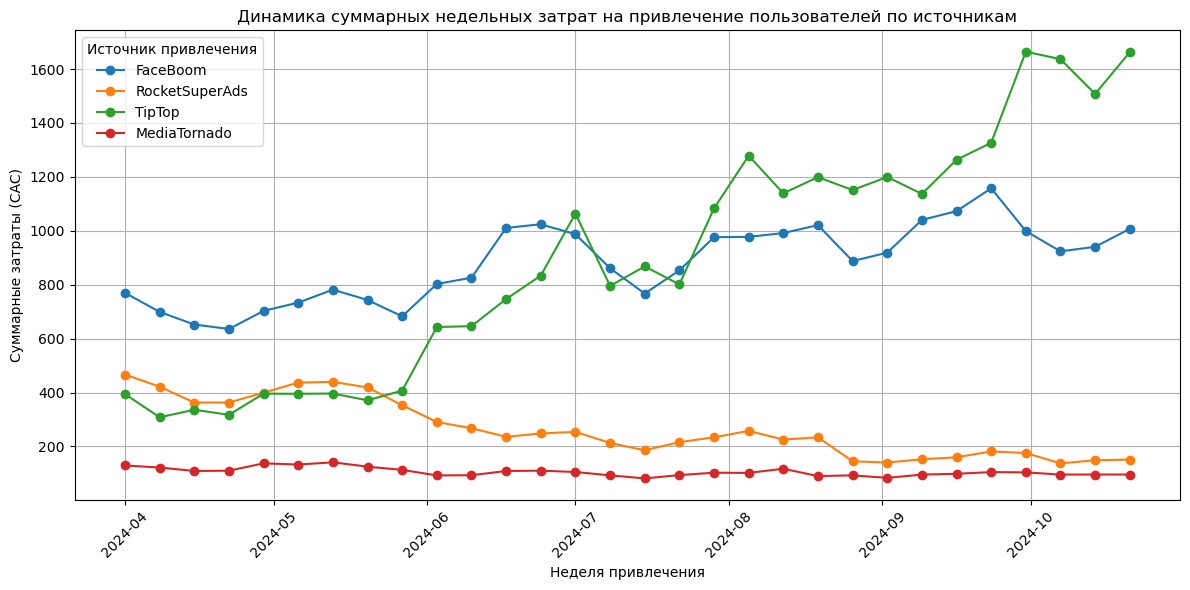

Канал привлечения FaceBoom, Общие затраты на привлечение: 26446.31
Канал привлечения RocketSuperAds, Общие затраты на привлечение: 7915.62
Канал привлечения TipTop, Общие затраты на привлечение: 26967.33
Канал привлечения MediaTornado, Общие затраты на привлечение: 3175.83


In [46]:
# Визуализируем динамику затрат
plt.figure(figsize=(12, 6))

for channel in weekly_costs['first_channel'].unique():
    plt.plot(
        weekly_costs[weekly_costs['first_channel'] == channel]['acquisition_week'].dt.to_timestamp(),
        weekly_costs[weekly_costs['first_channel'] == channel]['cac'],
        marker='o',
        label=channel
    )

plt.title('Динамика суммарных недельных затрат на привлечение пользователей по источникам')
plt.xlabel('Неделя привлечения')
plt.ylabel('Суммарные затраты (CAC)')
plt.xticks(rotation=45)
plt.legend(title='Источник привлечения')
plt.grid()
plt.tight_layout()
plt.show()

# Даем описательную характеристику
for channel in weekly_costs['first_channel'].unique():
    total_cost = weekly_costs[weekly_costs['first_channel'] == channel]['cac'].sum()
    print(f'Канал привлечения {channel}, Общие затраты на привлечение: {total_cost:.2f}')

Имеем следующее:

Затраты на привлечение по каналам FaceBoom и TipTop на высоком уровне (26446 и 26967 соответственно), затраты по остальным двум каналам меньше более, чем в два раза - RocketSuperAds (7916) и MediaTornado (3176)

In [47]:
display(profiles.head(), orders.head())

print(profiles.columns, orders.columns)

,user_id,first_dt,first_channel,cac,acquisition_month,acquisition_week
0,26034876,2024-05-29,FaceBoom,0.953250,2024-05,2024-05-27/2024-06-02
1,69890364,2024-06-28,RocketSuperAds,0.604917,2024-06,2024-06-24/2024-06-30
2,75610104,2024-06-09,FaceBoom,1.196159,2024-06,2024-06-03/2024-06-09
3,76692397,2024-10-21,FaceBoom,1.147967,2024-10,2024-10-21/2024-10-27
4,80224421,2024-06-21,FaceBoom,1.208981,2024-06,2024-06-17/2024-06-23


,user_id,event_dt,revenue,first_dt,first_channel,lifetime,month,acquisition_week
0,771951256319,2024-04-01,2.99,2024-04-01,FaceBoom,0,2024-04,2024-04-01/2024-04-07
1,829942381059,2024-04-01,2.99,2024-04-01,FaceBoom,0,2024-04,2024-04-01/2024-04-07
2,727879856738,2024-04-01,14.99,2024-04-01,FaceBoom,0,2024-04,2024-04-01/2024-04-07
3,481270888930,2024-04-01,2.99,2024-04-01,TipTop,0,2024-04,2024-04-01/2024-04-07
4,844695029762,2024-04-01,2.99,2024-04-01,FaceBoom,0,2024-04,2024-04-01/2024-04-07


Index(['user_id', 'first_dt', 'first_channel', 'cac', 'acquisition_month',
       'acquisition_week'],
      dtype='object') Index(['user_id', 'event_dt', 'revenue', 'first_dt', 'first_channel',
       'lifetime', 'month', 'acquisition_week'],
      dtype='object')


In [48]:
# Группируем по неделям и каналу
cac_by_week = profiles.groupby(['acquisition_week', 'first_channel']).agg(
    total_costs=('cac', 'sum'),  # Сумма затрат на привлечение
    unique_users=('user_id', 'nunique')  # Количество уникальных пользователей
).reset_index()

cac_by_week['CAC'] = cac_by_week['total_costs'] / cac_by_week['unique_users']

In [49]:
# Группируем выручку по неделям и каналам
revenue_by_week = orders.groupby(['first_channel', 'acquisition_week'])['revenue'].sum().reset_index()
revenue_by_week = revenue_by_week.rename(columns={'revenue': 'total_revenue'})

# Объединяем данные о CAC и выручке
weekly_metrics = cac_by_week.merge(revenue_by_week, on=['acquisition_week', 'first_channel'], how='left')

# Рассчитываем LTV и ROI
weekly_metrics['LTV'] = weekly_metrics['total_revenue'] / weekly_metrics['unique_users']
weekly_metrics['ROI'] = (weekly_metrics['LTV'] - weekly_metrics['CAC']) / weekly_metrics['CAC'] * 100

In [50]:
display(weekly_metrics.head())
print(orders.columns)

,acquisition_week,first_channel,total_costs,unique_users,CAC,total_revenue,LTV,ROI
0,2024-04-01/2024-04-07,FaceBoom,769.875901,820,0.938873,380.36,0.463854,-50.594635
1,2024-04-01/2024-04-07,MediaTornado,129.318322,522,0.247736,191.43,0.366724,48.030068
2,2024-04-01/2024-04-07,RocketSuperAds,466.650000,542,0.860978,724.33,1.336402,55.219115
3,2024-04-01/2024-04-07,TipTop,393.989381,516,0.763545,795.40,1.541473,101.883614
4,2024-04-08/2024-04-14,FaceBoom,698.872741,749,0.933074,337.06,0.450013,-51.770905


Index(['user_id', 'event_dt', 'revenue', 'first_dt', 'first_channel',
       'lifetime', 'month', 'acquisition_week'],
      dtype='object')


In [51]:
# Фильтруем weekly_metrics
weekly_metrics = weekly_metrics[weekly_metrics['acquisition_week'] < '2024-11-01']

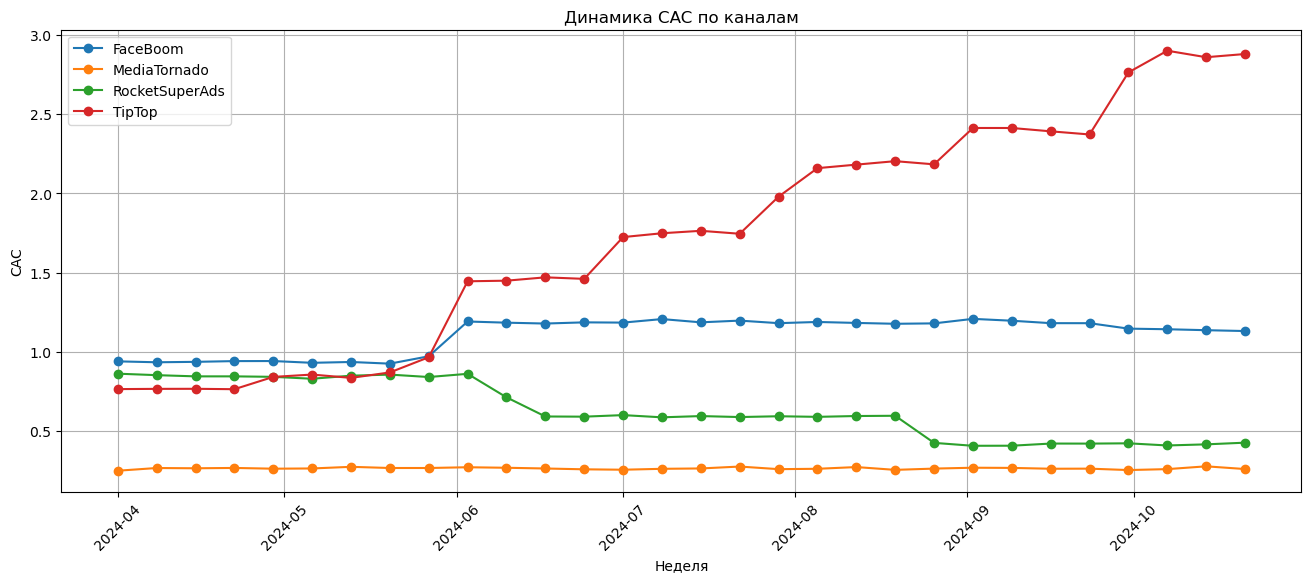

In [52]:
# Группировка по месяцам и каналам и расчёт среднего CAC 
cac_grouped = weekly_metrics.groupby(['acquisition_week','first_channel'])['CAC'].mean().reset_index()

# Построение графика
plt.figure(figsize=(16, 6))

# Цикл для построения графиков по каналам
for channel in cac_grouped['first_channel'].unique():
   df_plot = cac_grouped[cac_grouped['first_channel'] == channel]
   plt.plot(df_plot['acquisition_week'].dt.to_timestamp(), df_plot['CAC'], marker='o', label=channel)


# Настроим заголовок и метки
plt.xlabel('Неделя')
plt.ylabel('CAC')
plt.title('Динамика CAC по каналам')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

График показывает, что CAC по каналу TipTop сильно вырос к последней неделе 2024-12.

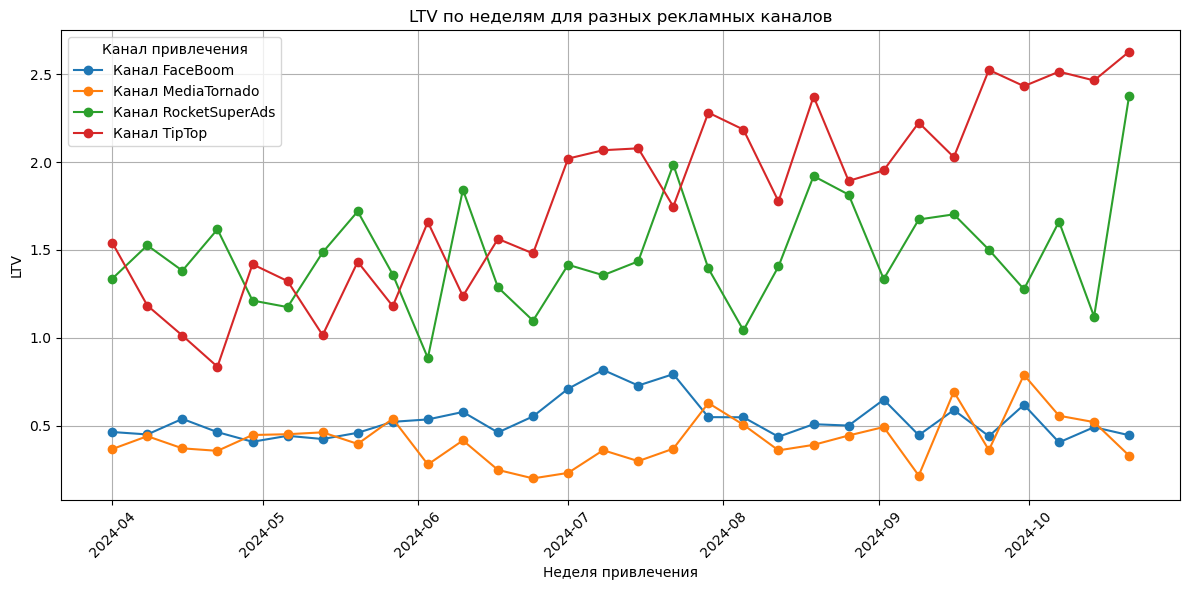

In [53]:
# Для каждой когорты посчитаем среднее значение LTV
df_grouped = weekly_metrics.groupby(['acquisition_week', 'first_channel'])['LTV'].mean().reset_index()

# Создадим график
plt.figure(figsize=(12, 6))

# Получаем уникальные каналы из df_grouped
unique_channels = df_grouped['first_channel'].unique()

# Построим линии для каждого уникального канала
for channel in unique_channels:
    df_plot = df_grouped[df_grouped['first_channel'] == channel]  
    plt.plot(df_plot['acquisition_week'].dt.to_timestamp(), df_plot['LTV'], marker='o', label=f'Канал {channel}')

# Добавим заголовок и подписи осей
plt.title('LTV по неделям для разных рекламных каналов')
plt.xlabel('Неделя привлечения')
plt.ylabel('LTV')
plt.legend(title='Канал привлечения')
plt.grid(True)
plt.xticks(rotation=45)  
plt.tight_layout()  
plt.show()

График показывает, что недельный LTV по каждому каналу колеблется, сильные колебания мы наблюдаем по каналу RocketSuperAds, а также по TipTop. Однако метрика падает у двух источников привлечения к ноябрю - это FaceBoom и MediaTornado.

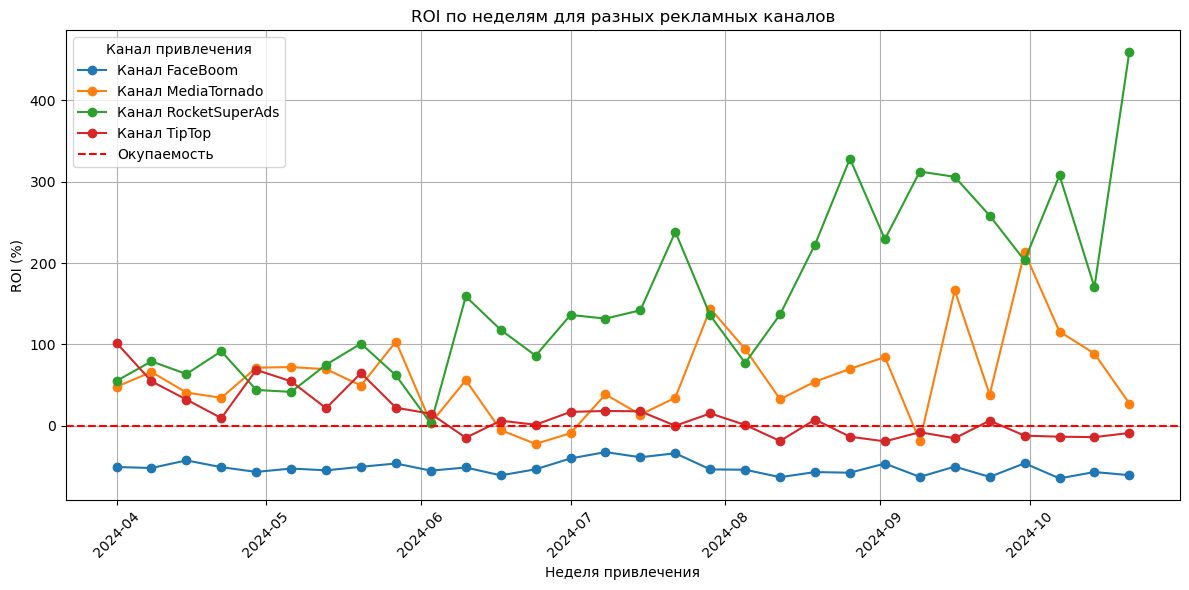

In [54]:
# Сгруппируем по когортам
df_grouped_ROI = weekly_metrics.groupby(['acquisition_week', 'first_channel'])['ROI'].mean().reset_index()

# Создадим график
plt.figure(figsize=(12, 6))

# Получаем уникальные каналы из df_grouped_ROI
unique_channels = df_grouped_ROI['first_channel'].unique()

# Построим линии для каждого уникального канала
for channel in unique_channels:
    df_plot = df_grouped_ROI[df_grouped_ROI['first_channel'] == channel]
    plt.plot(df_plot['acquisition_week'].dt.to_timestamp(), df_plot['ROI'], marker='o', label=f'Канал {channel}')

# Добавим линию, выше которой когорта окупается
plt.axhline(y=0, linestyle='--', color='red', label='Окупаемость')

# Оформим график
plt.title('ROI по неделям для разных рекламных каналов')
plt.xlabel('Неделя привлечения')
plt.ylabel('ROI (%)')
plt.legend(title='Канал привлечения')
plt.grid(True)
plt.xticks(rotation=45)  
plt.tight_layout()
plt.show()

График показывает, что канал FaceBoom стабильно не окупается. По каналу TipTop показатель ROI сначала давал прибыль, а затем к ноябрю перестал окупаться и опустился даже чуть ниже FaceBoom. Окупаемость MediaTornado имеет ярко выраженные колебания и в конце также утрачивает окупательскую способность.

## Анализ периода окупаемости маркетинговых вложений

Для источников, которые к 28-му дню не выходят на уровень окупаемости, рассчитайте и визуализируйте в виде тепловой карты значения ROI за больший период, например за 8–10 недель.

Разделите данные на недельные когорты по дате привлечения, в качестве интервала наблюдений используйте недели.

Сделайте вывод о том, за какой период окупаются вложения в эти источники.

Исходя из графика выше приходим к выводу, что у нас два канала, которые не окупаются -'FaceBoom', 'TipTop'

In [55]:
# Оставляем данные по каналам, которые не окупаются
full_orders = full_orders[full_orders['first_channel'].isin(['FaceBoom', 'TipTop'])]

In [56]:
# Выделяем неделю покупки
full_orders['purchase_week'] = full_orders['event_dt'].dt.to_period('W')

# Выделяем неделю привлечения
full_orders['acquisition_week'] = full_orders['first_dt'].dt.to_period('W')

display(full_orders.head())

,user_id,event_dt,revenue,first_dt,first_channel,lifetime,purchase_week,acquisition_week
0,771951256319,2024-04-01,2.99,2024-04-01,FaceBoom,0,2024-04-01/2024-04-07,2024-04-01/2024-04-07
1,829942381059,2024-04-01,2.99,2024-04-01,FaceBoom,0,2024-04-01/2024-04-07,2024-04-01/2024-04-07
2,727879856738,2024-04-01,14.99,2024-04-01,FaceBoom,0,2024-04-01/2024-04-07,2024-04-01/2024-04-07
3,481270888930,2024-04-01,2.99,2024-04-01,TipTop,0,2024-04-01/2024-04-07,2024-04-01/2024-04-07
4,844695029762,2024-04-01,2.99,2024-04-01,FaceBoom,0,2024-04-01/2024-04-07,2024-04-01/2024-04-07


In [57]:
# Преобразование столбцов в Timestamp, если они имеют тип Period
if pd.api.types.is_period_dtype(full_orders['purchase_week']):
    full_orders['purchase_week'] = full_orders['purchase_week'].dt.to_timestamp()

if pd.api.types.is_period_dtype(full_orders['acquisition_week']):
    full_orders['acquisition_week'] = full_orders['acquisition_week'].dt.to_timestamp()

# Рассчитываем количество недель между acquisition_week и event_dt
full_orders['week_period'] = ((full_orders['purchase_week'] - full_orders['acquisition_week']).dt.days // 7) + 1
# +1 нужно, чтобы недели отображались не с 0

In [58]:
full_orders = full_orders.drop(columns=['lifetime'])

# Проверяем результат
display(full_orders.head(), full_orders.columns)

,user_id,event_dt,revenue,first_dt,first_channel,purchase_week,acquisition_week,week_period
0,771951256319,2024-04-01,2.99,2024-04-01,FaceBoom,2024-04-01,2024-04-01,1
1,829942381059,2024-04-01,2.99,2024-04-01,FaceBoom,2024-04-01,2024-04-01,1
2,727879856738,2024-04-01,14.99,2024-04-01,FaceBoom,2024-04-01,2024-04-01,1
3,481270888930,2024-04-01,2.99,2024-04-01,TipTop,2024-04-01,2024-04-01,1
4,844695029762,2024-04-01,2.99,2024-04-01,FaceBoom,2024-04-01,2024-04-01,1


Index(['user_id', 'event_dt', 'revenue', 'first_dt', 'first_channel',
       'purchase_week', 'acquisition_week', 'week_period'],
      dtype='object')

In [59]:
weekly_revenue = full_orders.groupby(['first_channel', 'acquisition_week'])['revenue'].sum().reset_index(name='total_weekly_revenue')
display(weekly_revenue.head())

,first_channel,acquisition_week,total_weekly_revenue
0,FaceBoom,2024-04-01,393.82
1,FaceBoom,2024-04-08,344.54
2,FaceBoom,2024-04-15,399.33
3,FaceBoom,2024-04-22,330.05
4,FaceBoom,2024-04-29,328.92


In [60]:
costs_by_channel_date = costs.groupby(['channel', 'dt'])['costs'].sum().reset_index()

In [61]:
# Выделяем неделю покупки
costs_by_channel_date['purchase_week'] = costs_by_channel_date['dt'].dt.to_period('W')

if pd.api.types.is_period_dtype(costs_by_channel_date['purchase_week']):
    costs_by_channel_date['purchase_week'] = costs_by_channel_date['purchase_week'].dt.to_timestamp()

In [62]:
profiles_for_weekly_ROI['acquisition_week'] = profiles_for_weekly_ROI['first_dt'].dt.to_period('W')

if pd.api.types.is_period_dtype(profiles_for_weekly_ROI['acquisition_week']):
    profiles_for_weekly_ROI['acquisition_week'] = profiles_for_weekly_ROI['acquisition_week'].dt.to_timestamp()

In [63]:
# Группируем по неделям и каналу

weekly_cac = profiles_for_weekly_ROI.groupby(['acquisition_week', 'first_channel']).agg(
    total_costs=('cac', 'sum'),  # Сумма затрат на привлечение
    unique_users=('user_id', 'nunique')  # Количество уникальных пользователей
).reset_index()

weekly_cac['CAC'] = weekly_cac['total_costs'] / cac_by_week['unique_users']

display(weekly_cac.head())

,acquisition_week,first_channel,total_costs,unique_users,CAC
0,2024-04-01,FaceBoom,769.875901,820,0.938873
1,2024-04-01,MediaTornado,129.318322,522,0.247736
2,2024-04-01,RocketSuperAds,466.650000,542,0.860978
3,2024-04-01,TipTop,393.989381,516,0.763545
4,2024-04-08,FaceBoom,698.872741,749,0.933074


In [64]:
for_weekly_ROI = pd.merge(full_orders[['first_channel', 'acquisition_week', 'week_period']], weekly_cac[['first_channel','acquisition_week', 'CAC', 'unique_users']], on = ['first_channel','acquisition_week'],  how = 'left')

In [65]:
for_weekly_ROI = weekly_revenue.merge(for_weekly_ROI, on = ['first_channel', 'acquisition_week'], how = 'left')

# Рассчитываем LTV и ROI
for_weekly_ROI['LTV'] = for_weekly_ROI['total_weekly_revenue'] / for_weekly_ROI['unique_users']
for_weekly_ROI['ROI'] = (for_weekly_ROI['LTV'] - for_weekly_ROI['CAC']) / for_weekly_ROI['CAC'] * 100

display(for_weekly_ROI.head())

,first_channel,acquisition_week,total_weekly_revenue,week_period,CAC,unique_users,LTV,ROI
0,FaceBoom,2024-04-01,393.82,1,0.938873,820,0.480268,-48.846301
1,FaceBoom,2024-04-01,393.82,1,0.938873,820,0.480268,-48.846301
2,FaceBoom,2024-04-01,393.82,1,0.938873,820,0.480268,-48.846301
3,FaceBoom,2024-04-01,393.82,1,0.938873,820,0.480268,-48.846301
4,FaceBoom,2024-04-01,393.82,1,0.938873,820,0.480268,-48.846301


In [66]:
for_weekly_ROI = for_weekly_ROI[for_weekly_ROI['week_period'] <= 10]

Строим тепловые карты

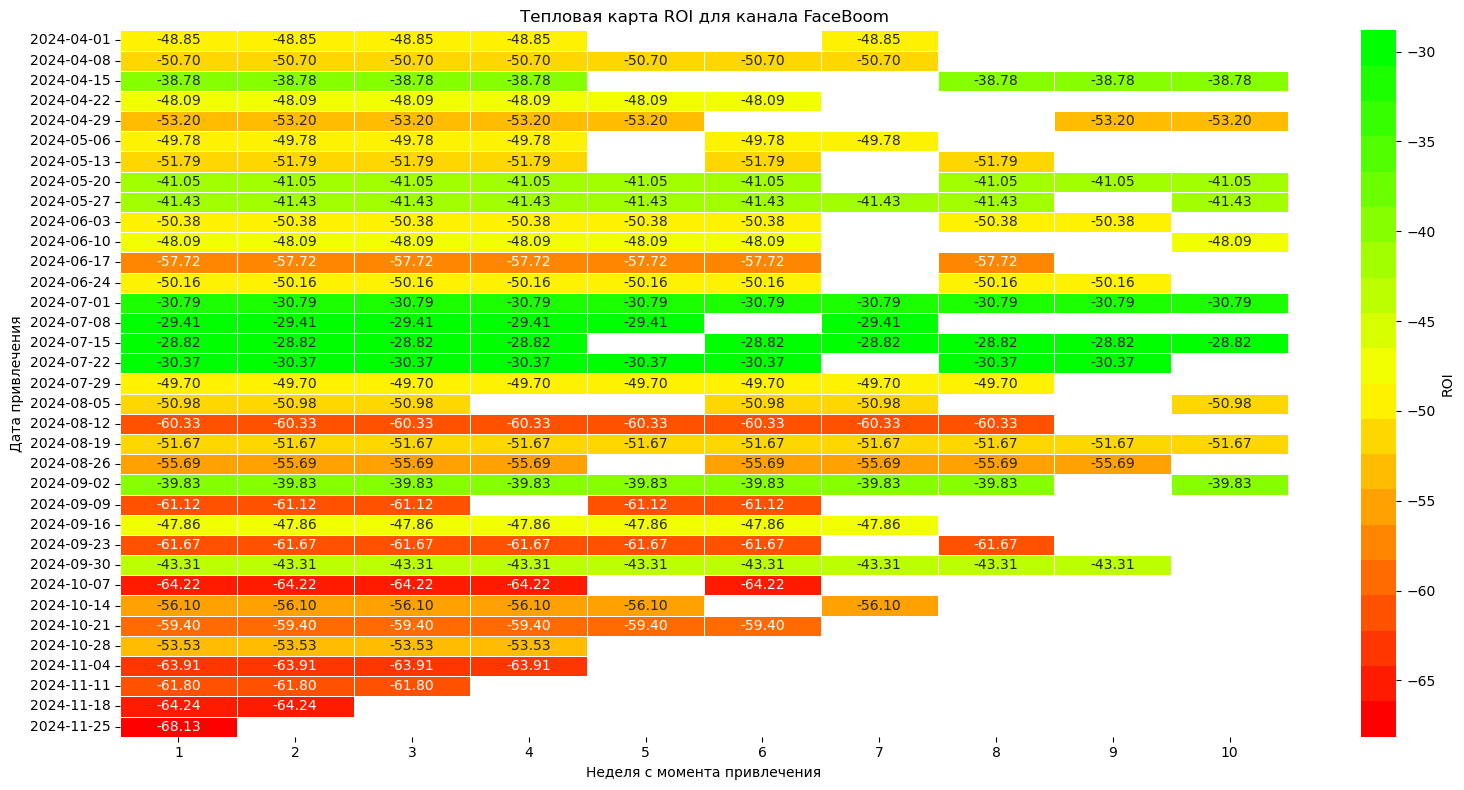

In [67]:
# Для канала FaceBoom

channel_data = for_weekly_ROI[for_weekly_ROI['first_channel'] == 'FaceBoom'].groupby(['first_channel', 'acquisition_week', 'week_period'])['ROI'].mean().reset_index()

pivot_table = channel_data.pivot_table(
        index='acquisition_week',  # Используем неделю привлечения
        columns='week_period',  # Столбцы - количество недель с момента привлечения
        values='ROI')

# Заменяем нули на NaN для лучшей визуализации
pivot_table[pivot_table == 0] = float('nan')

# Настраиваем цветовую палитру
cmap = mcolors.LinearSegmentedColormap.from_list('bright_red_green', ['#FF0000', '#FFFF00', '#00FF00'], N=20)

# Визуализация тепловой карты
pivot_table.index = pd.to_datetime(pivot_table.index).strftime('%Y-%m-%d')

plt.figure(figsize=(16, 8))
sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap=cmap, cbar_kws={'label': 'ROI'}, linewidths=.5)
plt.title(f'Тепловая карта ROI для канала FaceBoom')
plt.xlabel('Неделя с момента привлечения')
plt.ylabel('Дата привлечения')

plt.tight_layout()

plt.show()

График показывает, что FaceBoom вообще не окупается, начиная с первой недели привлечения, метрика проседает c -48.85 до -68 к 2024-11-25

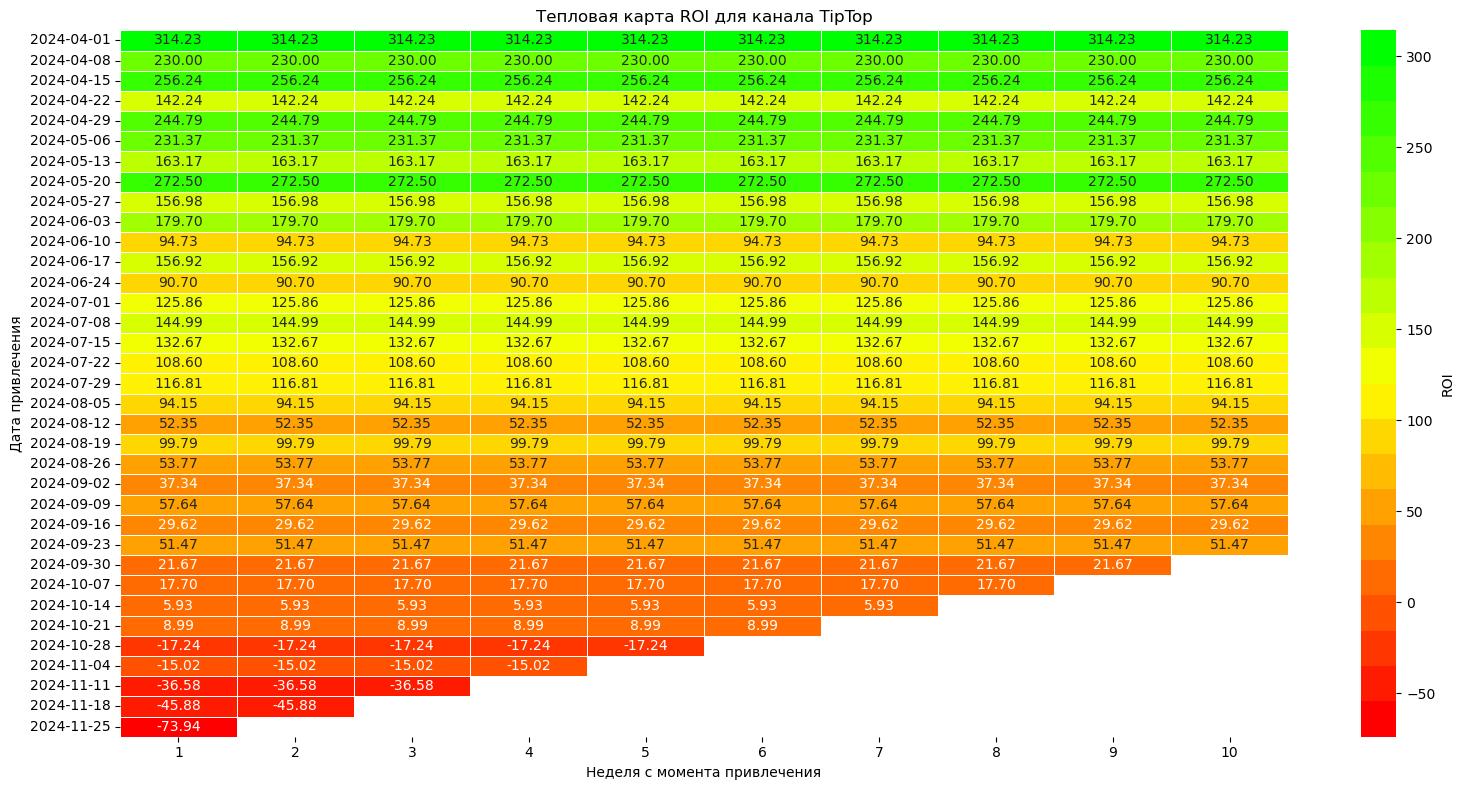

In [68]:
# Для канала TipTop

channel_data = for_weekly_ROI[for_weekly_ROI['first_channel'] == 'TipTop'].groupby(['first_channel', 'acquisition_week', 'week_period'])['ROI'].mean().reset_index()

pivot_table = channel_data.pivot_table(
        index='acquisition_week',  # Используем неделю привлечения
        columns='week_period',  # Столбцы - количество недель с момента привлечения
        values='ROI')


# Заменяем нули на NaN для лучшей визуализации
pivot_table[pivot_table == 0] = float('nan')

# Настраиваем цветовую палитру
cmap = mcolors.LinearSegmentedColormap.from_list('bright_red_green', ['#FF0000', '#FFFF00', '#00FF00'], N=20)

# Визуализация тепловой карты
pivot_table.index = pd.to_datetime(pivot_table.index).strftime('%Y-%m-%d')

plt.figure(figsize=(16, 8))
sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap=cmap, cbar_kws={'label': 'ROI'}, linewidths=.5)
plt.title(f'Тепловая карта ROI для канала TipTop')
plt.xlabel('Неделя с момента привлечения')
plt.ylabel('Дата привлечения')
plt.tight_layout()

plt.show()

График показывает, что TipTop не окупается, начиная с первой недели привлечения, метрика падает со значения 314.23, и составляет -73.94

## Выводы и рекомендации

Имеем следующее:

Рост активности пользователей:

- График дневного DAU демонстрирует колебания, однако в целом наблюдается тенденция к росту дневной активности пользователей, что может свидетельствовать о повышении интереса к приложению.
- Аналогично, месячная активность MAU также растет, хотя и с просадками в мае-июне и августе-сентябре 2024 года. Это указывает на возможные сезонные колебания в использовании приложения.

Стагнация выручки:

- Несмотря на рост DAU и MAU, уровень вовлеченности остается низким (5-6%), что говорит о том, что менее 10% пользователей возвращаются в приложение ежедневно. Это может быть признаком недостаточной ценности контента или проблем с пользовательским опытом.

Растущие затраты на маркетинг:

- Месячные затраты на маркетинг быстро растут, но не приводят к пропорциональному увеличению выручки, что указывает на необходимость оптимизации маркетинговых расходов и стратегий.

Проблемы с LTV и ROI:

- LTV показывает резкий рост с начала лета, затем наблюдается небольшой спад до августа, после чего метрика стабилизируется с тенденцией к росту до октября.
- ROI падает в период с мая по июнь, затем резко возрастает в июле, но снова падает до октября. Причины этого поведения могут быть связаны с тем, что затраты на привлечение пользователей возросли, но доходы от них не увеличились пропорционально.

Разница в производительности каналов:

- Наибольшее количество новых пользователей было привлечено через канал FaceBoom, что свидетельствует о его эффективности. Второе место занимает канал TipTop.
- Дневная и месячная активность пользователей по каналу TipTop растет к концу года, в то время как остальные каналы демонстрируют стабильность с колебаниями.

Stickiness и Retention Rate:

- Stickiness по каналу TipTop сначала снижается, затем резко растет, в то время как месячный Stickiness для других каналов остается стабильным. Наименьшее залипание наблюдается у FaceBoom.
- RR по TipTop растет с начала лета до октября 2024 года, тогда как у FaceBoom он остается самым низким среди всех источников.

Качество привлеченных пользователей:

- Недельный CAC по TipTop сильно вырос к последней неделе 2024 года, что может указывать на проблемы с эффективностью рекламы.
- Недельный LTV колебался, с сильными колебаниями по RocketSuperAds и TipTop. Однако LTV падает у FaceBoom и MediaTornado к ноябрю.
- Канал FaceBoom стабильно не окупается, ROI падает с -48.85 до -68 к 2024-11-25. Аналогично, TipTop также не окупается, с ROI, падающим с 314.23 до -73.94.

Скачкообразные колебания:

- Конверсии по каналам имеют скачкообразный вид, что может быть связано с изменением маркетинговой стратегии в начале лета.
- Затраты на привлечение по FaceBoom и TipTop остаются высокими, тогда как RocketSuperAds и MediaTornado имеют значительно меньшие затраты.

На основании расчетов, а также визуализаций я могу дать такие рекомендации:   
    
- Пересмотреть стратегии привлечения пользователей, особенно по каналам с низким ROI, и сосредоточиться на более эффективных каналах.
- Провести анализ пользовательского опыта и контента для повышения вовлеченности и удержания пользователей.
- Изучить поведение различных сегментов пользователей для более точного таргетирования и персонализации предложений.
- Установить регулярный мониторинг ключевых метрик (DAU, MAU, LTV, ROI) для более быстрого реагирования на изменения в поведении пользователей.